In [149]:
import numpy as np
import matplotlib.pyplot as plt

In [150]:
with np.load("data/mnist.npz") as data:
      X = np.concatenate(
          [data["x_train"], data["x_test"]],
          axis=0
      )

      y = np.concatenate(
          [data["y_train"], data["y_test"]],
          axis=0
      )

In [151]:
def two_level_binarize(images, threshold=127, low=0, high=1):
    return np.where(images > threshold, high, low).astype(np.float32)

In [152]:
X_gray = X
X_gray_float = X_gray.astype(np.float32) / 255.0

thresholds = [8, 127, 248]
widths = [0.05, 0.1, 0.2]

level_ranges = [
    {"range": "full", "width": 1.0, "low": 0.0, "high": 1.0},
]

for width in widths:
    level_ranges.append({
        "range": "lower",
        "width": width,
        "low": 0.0,
        "high": round(width, 3),
    })

for width in widths:
    level_ranges.append({
        "range": "middle",
        "width": width,
        "low": round(0.5 - width / 2, 3),
        "high": round(0.5 + width / 2, 3),
    })

for width in widths:
    level_ranges.append({
        "range": "upper",
        "width": width,
        "low": round(1.0 - width, 3),
        "high": 1.0,
    })

binarization_configs = []

for threshold in thresholds:
    for levels in level_ranges:
        width_tag = str(levels['width']).replace('.', 'p')
        name = (
            f"binary_t{threshold}_{levels['range']}_w{width_tag}"
        )
        binarization_configs.append({
            "name": name,
            "threshold": threshold,
            "low": levels["low"],
            "high": levels["high"],
            "range": levels["range"],
            "width": levels["width"],
            "description": (
                f"Порог {threshold}; уровни "
                f"{levels['low']} и {levels['high']}; "
                f"ширина диапазона {levels['width']}."
            ),
        })

In [153]:
def add_uniform_noise(
    images, noise_probability, delta=None, levels=None, seed=None
):
    images = np.asarray(images, dtype=np.float32)
    if (delta is None) == (levels is None):
        raise ValueError("Укажите ровно один режим: delta или levels")

    probability = np.asarray(noise_probability, dtype=np.float32)
    if np.any((probability < 0.0) | (probability > 1.0)):
        raise ValueError("Вероятность шума должна быть в диапазоне [0, 1]")

    rng = np.random.default_rng(seed)

    selected = rng.random(images.shape) < probability

    if levels is None:
        lower = np.maximum(0.0, images - delta)
        upper = np.minimum(1.0, images + delta)
        noisy_values = rng.uniform(lower, upper).astype(np.float32)
    else:
        low, high = levels
        noisy_values = np.where(
            np.isclose(images, low), high, low
        ).astype(np.float32)

    return np.where(selected, noisy_values, images).astype(np.float32)


def plot_uniform_noise_comparison(
    images, labels, indices, probabilities,
    delta=None, levels=None, seed=None
):
    indices = np.asarray(indices)
    selected_images = np.asarray(images)[indices]
    selected_labels = np.asarray(labels)[indices]
    rows = [("Исходное", selected_images)]

    for probability in probabilities:
        rows.append((
            f"p = {probability:.2f}",
            add_uniform_noise(
                selected_images,
                noise_probability=probability,
                delta=delta,
                levels=levels,
                seed=seed,
            ),
        ))

    figure, axes = plt.subplots(
        len(rows),
        len(indices),
        figsize=(2.3 * len(indices), 2.1 * len(rows)),
        squeeze=False,
    )

    for row, (row_name, row_images) in enumerate(rows):
        for column in range(len(indices)):
            axis = axes[row, column]
            axis.imshow(
                row_images[column], cmap="gray", vmin=0.0, vmax=1.0
            )
            if row == 0:
                axis.set_title(
                    f"index={indices[column]}, "
                    f"class={selected_labels[column]}"
                )
            axis.set_xticks([])
            axis.set_yticks([])
            axis.set_frame_on(False)
        axes[row, 0].set_ylabel(row_name)

    figure.tight_layout()
    return figure


def contour_strength(images):
    images = np.asarray(images, dtype=np.float32)
    strength = np.zeros_like(images)

    horizontal_difference = np.abs(
        images[..., :, 1:] - images[..., :, :-1]
    )
    strength[..., :, 1:] += horizontal_difference
    strength[..., :, :-1] += horizontal_difference

    vertical_difference = np.abs(
        images[..., 1:, :] - images[..., :-1, :]
    )
    strength[..., 1:, :] += vertical_difference
    strength[..., :-1, :] += vertical_difference

    maximum = strength.max(axis=(-2, -1), keepdims=True)
    safe_maximum = np.where(maximum > 0, maximum, 1.0)
    return (strength / safe_maximum).astype(np.float32)


def contour_probability_map(images, p_min, p_max, gamma=1.0):
    if not 0.0 <= p_min <= p_max <= 1.0:
        raise ValueError("Требуется 0 <= p_min <= p_max <= 1")
    if gamma <= 0:
        raise ValueError("gamma должна быть положительной")

    strength = contour_strength(images)
    probabilities = p_min + (p_max - p_min) * strength ** gamma
    return probabilities.astype(np.float32)


def add_contour_noise(
    images, p_min, p_max, gamma=1.0,
    delta=None, levels=None, seed=None
):
    probabilities = contour_probability_map(
        images, p_min=p_min, p_max=p_max, gamma=gamma
    )
    return add_uniform_noise(
        images,
        noise_probability=probabilities,
        delta=delta,
        levels=levels,
        seed=seed,
    )


def plot_contour_noise_examples(
    images, labels, indices, p_min, p_max, gamma=1.0,
    delta=None, levels=None, seed=None
):
    indices = np.asarray(indices)
    selected_images = np.asarray(images)[indices]
    selected_labels = np.asarray(labels)[indices]
    strength = contour_strength(selected_images)
    probabilities = contour_probability_map(
        selected_images, p_min=p_min, p_max=p_max, gamma=gamma
    )
    noisy_images = add_contour_noise(
        selected_images,
        p_min=p_min,
        p_max=p_max,
        gamma=gamma,
        delta=delta,
        levels=levels,
        seed=seed,
    )

    stages = [
        ("Исходное", selected_images, "gray", 0.0, 1.0),
        ("Сила контура", strength, "magma", 0.0, 1.0),
        ("Вероятность", probabilities, "viridis", p_min, p_max),
        ("Результат", noisy_images, "gray", 0.0, 1.0),
    ]
    figure, axes = plt.subplots(
        len(stages),
        len(indices),
        figsize=(2.3 * len(indices), 8.5),
        squeeze=False,
    )

    for row, (stage_name, stage_images, cmap, vmin, vmax) in enumerate(stages):
        for column in range(len(indices)):
            axis = axes[row, column]
            axis.imshow(
                stage_images[column], cmap=cmap, vmin=vmin, vmax=vmax
            )
            if row == 0:
                axis.set_title(
                    f"index={indices[column]}, class={selected_labels[column]}"
                )
            axis.set_xticks([])
            axis.set_yticks([])
            axis.set_frame_on(False)
        axes[row, 0].set_ylabel(stage_name)

    figure.tight_layout()
    return figure


## Примеры вариантов выборки

Во всех строках показаны изображения с одинаковыми индексами, чтобы преобразования можно было сравнивать напрямую.

In [154]:
def plot_dataset_variants(variants, labels, indices):
    rows = len(variants)
    columns = len(indices)
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(2.2 * columns, 2.4 * rows),
        squeeze=False,
    )

    for row, (name, variant) in enumerate(variants.items()):
        images = variant["images"]
        vmin, vmax = variant.get(
            "display_range",
            (float(images.min()), float(images.max())),
        )

        for column, index in enumerate(indices):
            axis = axes[row, column]
            axis.imshow(images[index], cmap="gray", vmin=vmin, vmax=vmax)
            axis.set_title(f"index={index}, class={labels[index]}")
            axis.axis("off")

        axes[row, 0].set_ylabel(name)

    figure.tight_layout()
    return figure


Порог: 8
gray: Исходные изображения в градациях серого.
binary_t8_full_w1p0: Порог 8; уровни 0.0 и 1.0; ширина диапазона 1.0.
binary_t8_lower_w0p05: Порог 8; уровни 0.0 и 0.05; ширина диапазона 0.05.
binary_t8_lower_w0p1: Порог 8; уровни 0.0 и 0.1; ширина диапазона 0.1.
binary_t8_lower_w0p2: Порог 8; уровни 0.0 и 0.2; ширина диапазона 0.2.
binary_t8_middle_w0p05: Порог 8; уровни 0.475 и 0.525; ширина диапазона 0.05.
binary_t8_middle_w0p1: Порог 8; уровни 0.45 и 0.55; ширина диапазона 0.1.
binary_t8_middle_w0p2: Порог 8; уровни 0.4 и 0.6; ширина диапазона 0.2.
binary_t8_upper_w0p05: Порог 8; уровни 0.95 и 1.0; ширина диапазона 0.05.
binary_t8_upper_w0p1: Порог 8; уровни 0.9 и 1.0; ширина диапазона 0.1.
binary_t8_upper_w0p2: Порог 8; уровни 0.8 и 1.0; ширина диапазона 0.2.

Порог: 127
gray: Исходные изображения в градациях серого.
binary_t127_full_w1p0: Порог 127; уровни 0.0 и 1.0; ширина диапазона 1.0.
binary_t127_lower_w0p05: Порог 127; уровни 0.0 и 0.05; ширина диапазона 0.05.
binary

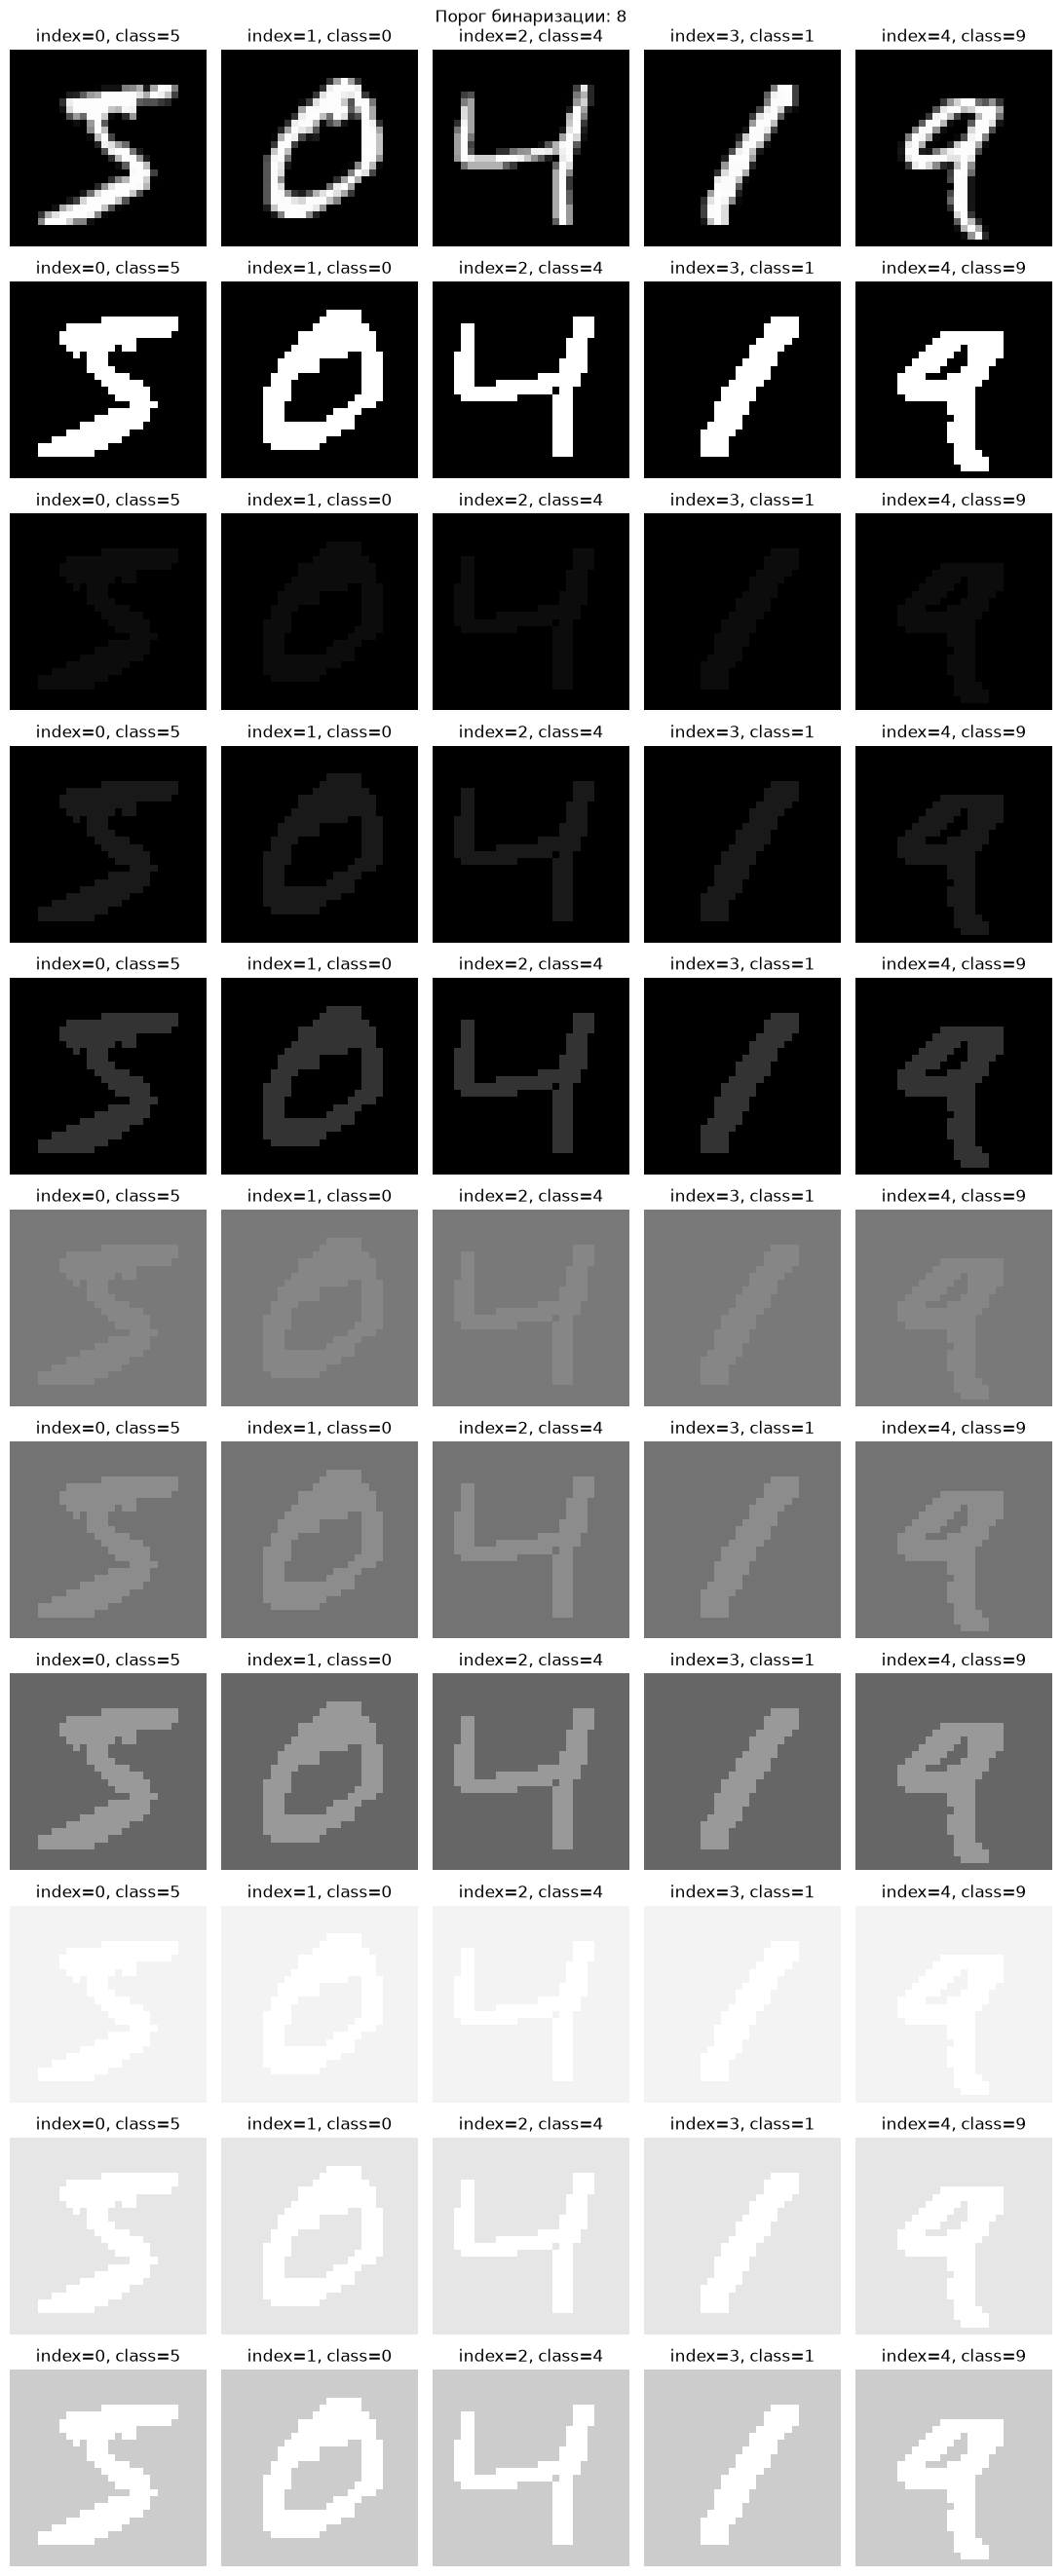

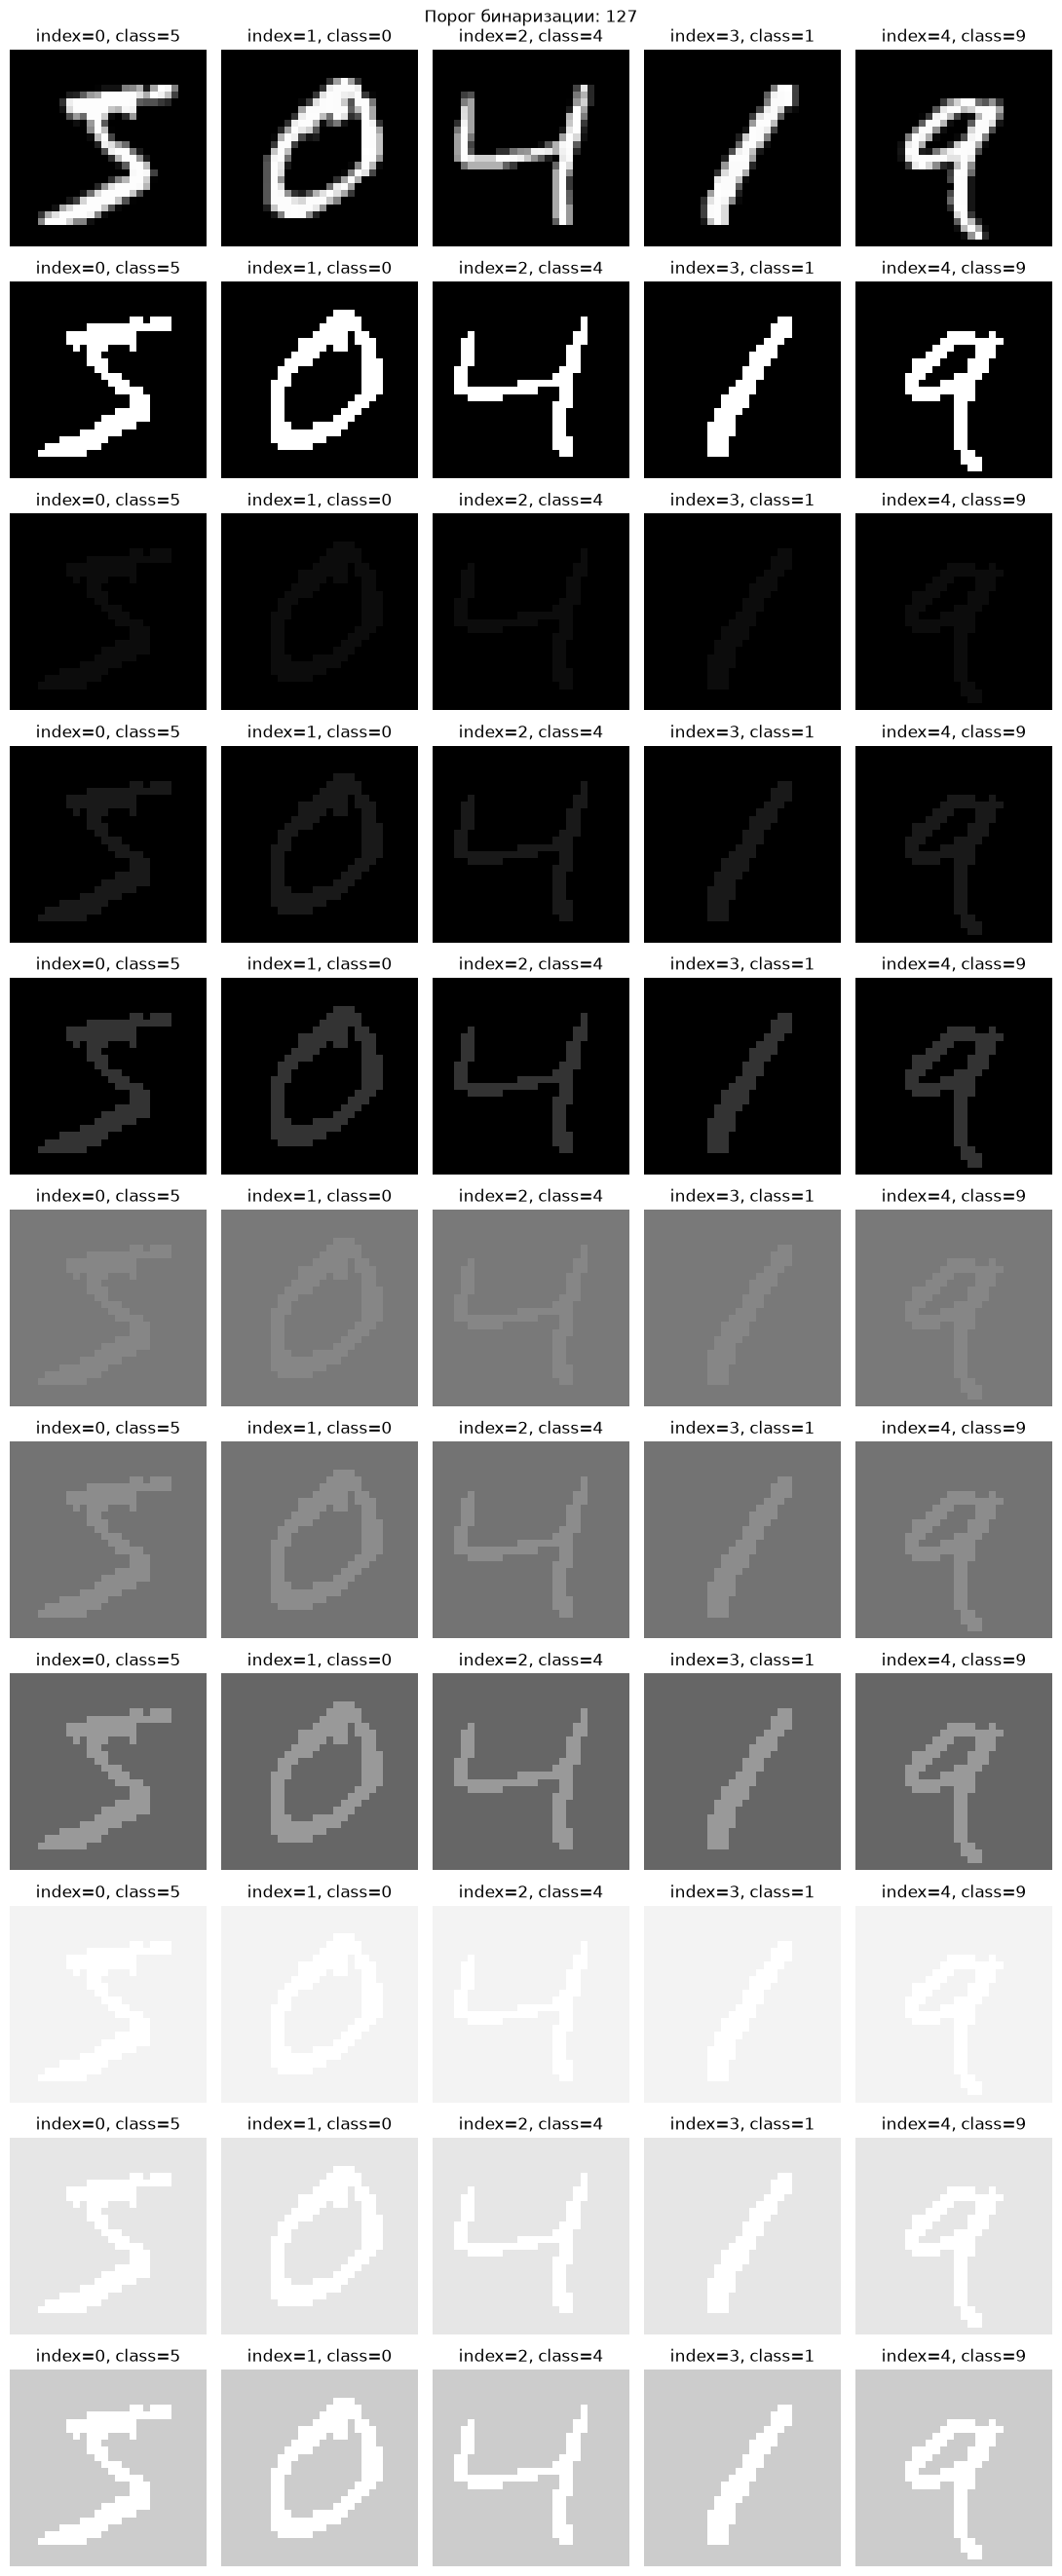

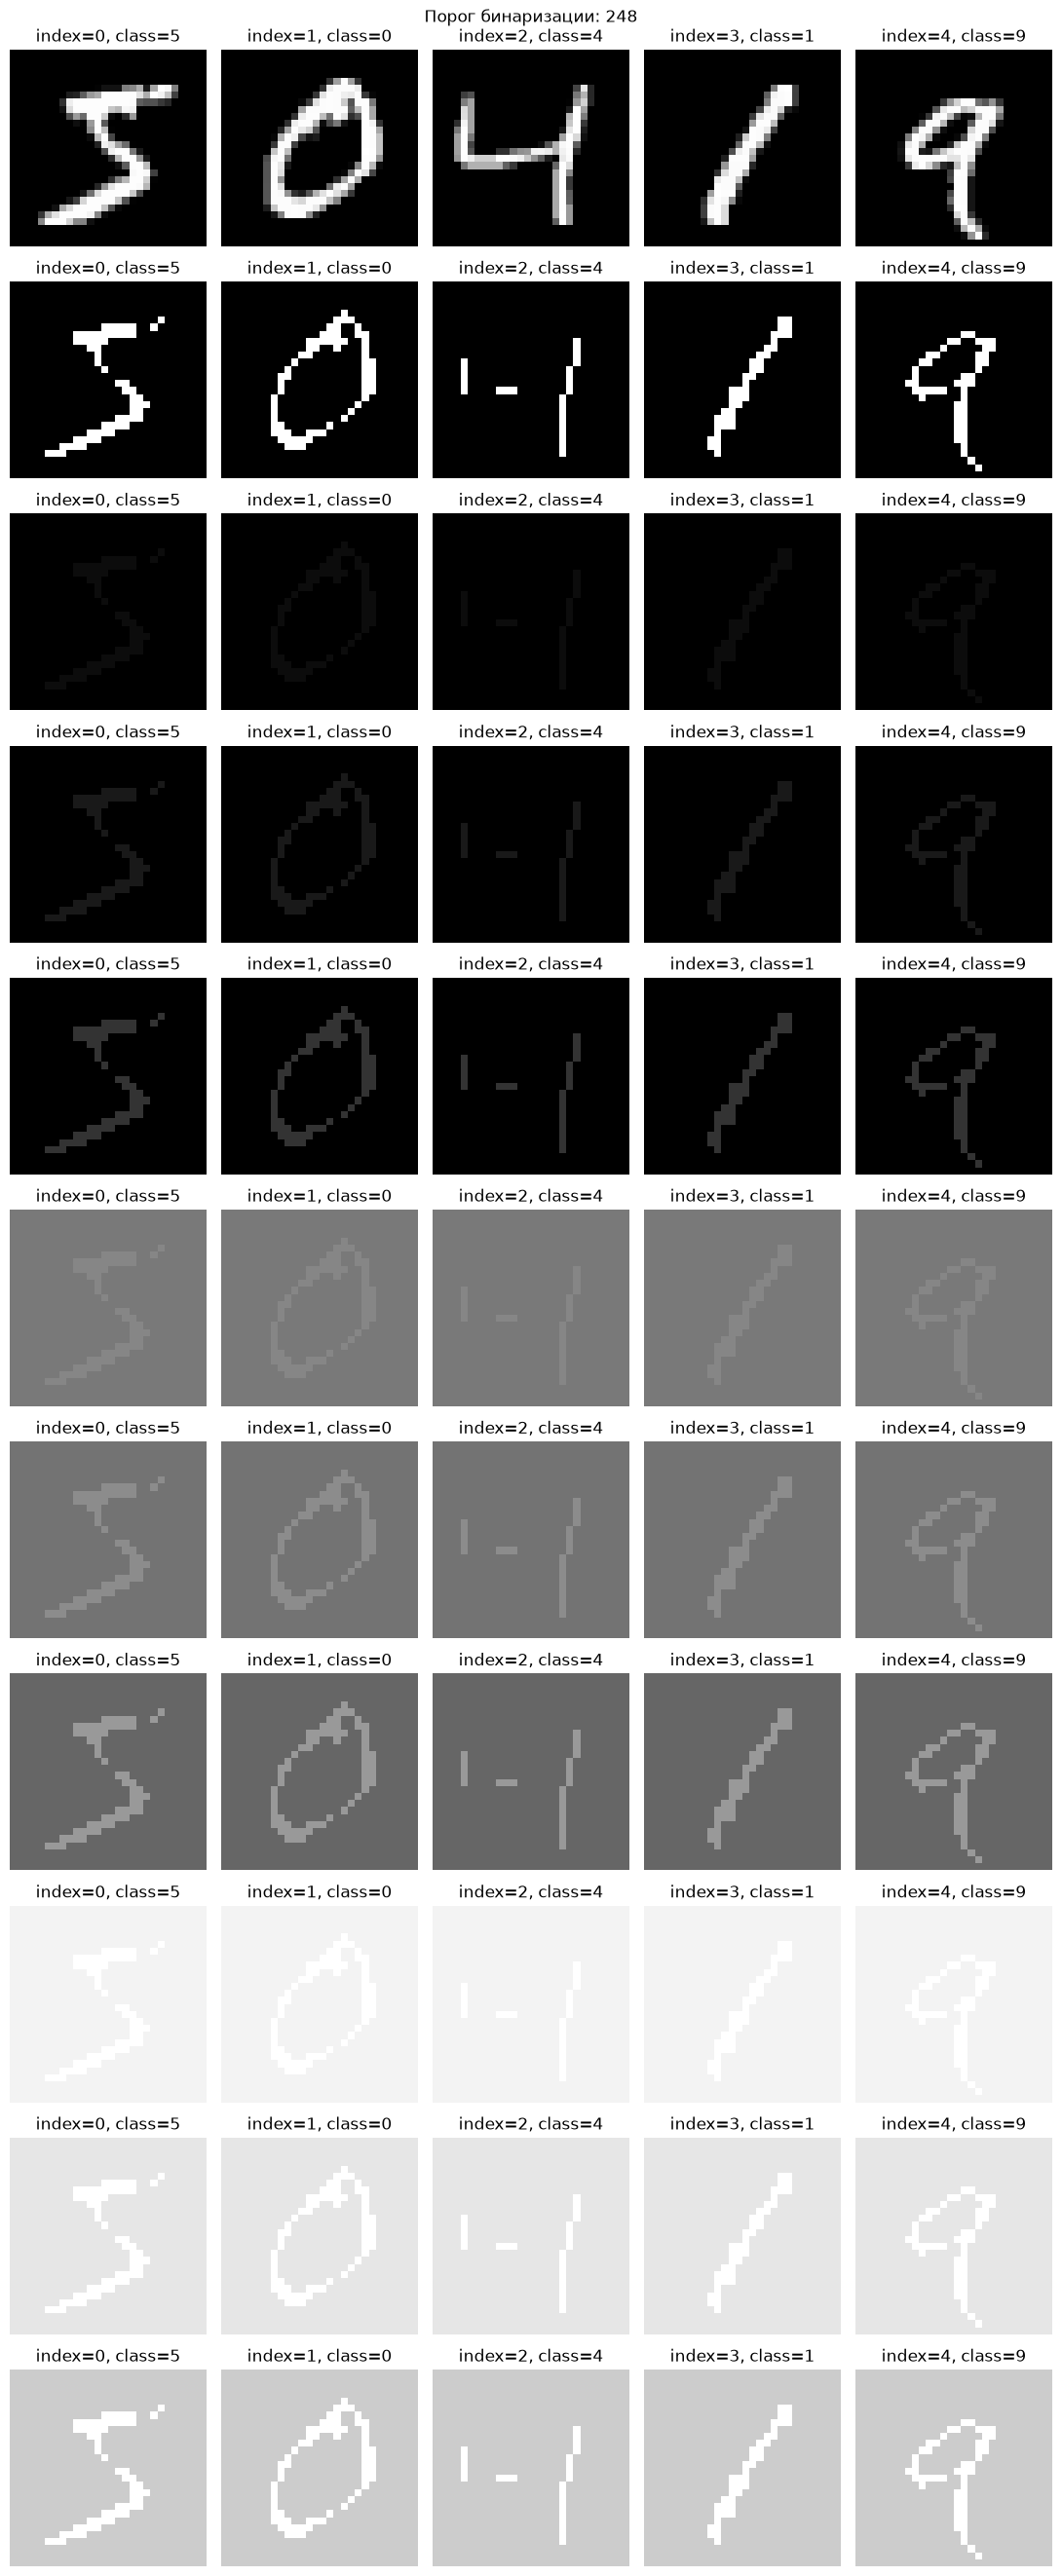

In [155]:
example_indices = [0, 1, 2, 3, 4]
example_images = X_gray[example_indices]
example_labels = y[example_indices]
example_variant_groups = {}

for threshold in thresholds:
    variants = {
        "gray": {
            "images": example_images,
            "description": "Исходные изображения в градациях серого.",
            "display_range": (0, 255),
        },
    }

    for config in binarization_configs:
        if config["threshold"] != threshold:
            continue

        variants[config["name"]] = {
            "images": two_level_binarize(
                example_images,
                threshold=config["threshold"],
                low=config["low"],
                high=config["high"],
            ),
            "description": config["description"],
            "parameters": config,
            "display_range": (0, 1),
        }

    example_variant_groups[threshold] = variants

comparison_figures = []

for threshold, variants in example_variant_groups.items():
    print(f"\nПорог: {threshold}")
    for name, variant in variants.items():
        print(f"{name}: {variant['description']}")

    figure = plot_dataset_variants(
        variants,
        labels=example_labels,
        indices=range(len(example_indices)),
    )
    figure.suptitle(f"Порог бинаризации: {threshold}", y=1.002)
    comparison_figures.append(figure)

plt.show()

## Равномерный шум: выбор вероятности `p`

Сравниваются одинаковые изображения при `p = 0.05, 0.10, 0.20, 0.30, 0.50`. Для серых изображений используется `delta=0.75`; в чёрно-белых изображениях выбранные пиксели переключаются между 0 и 1.


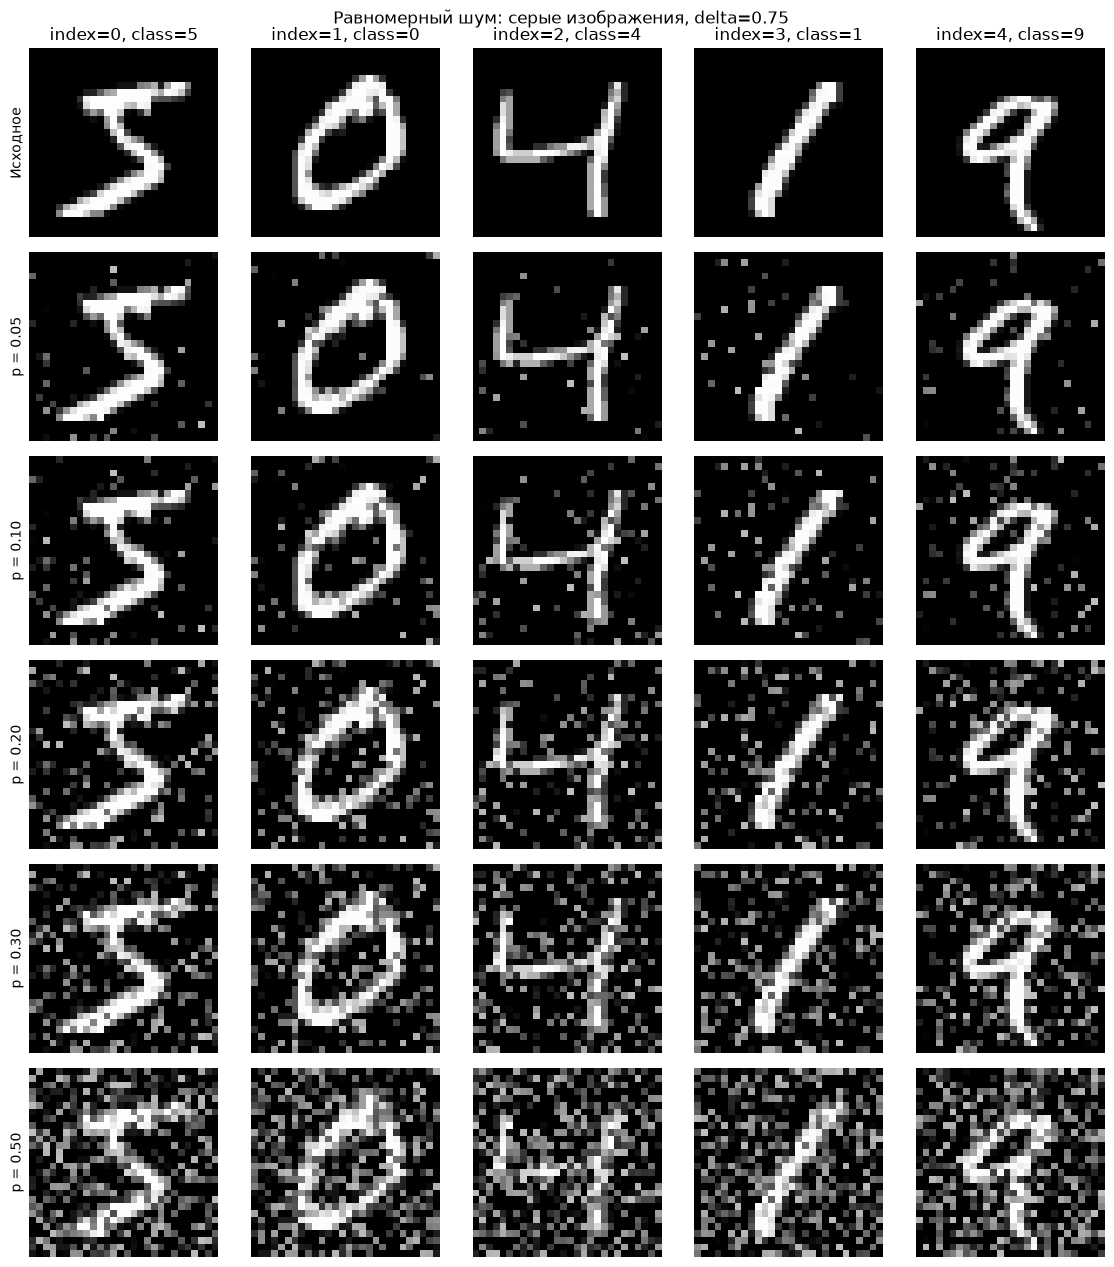

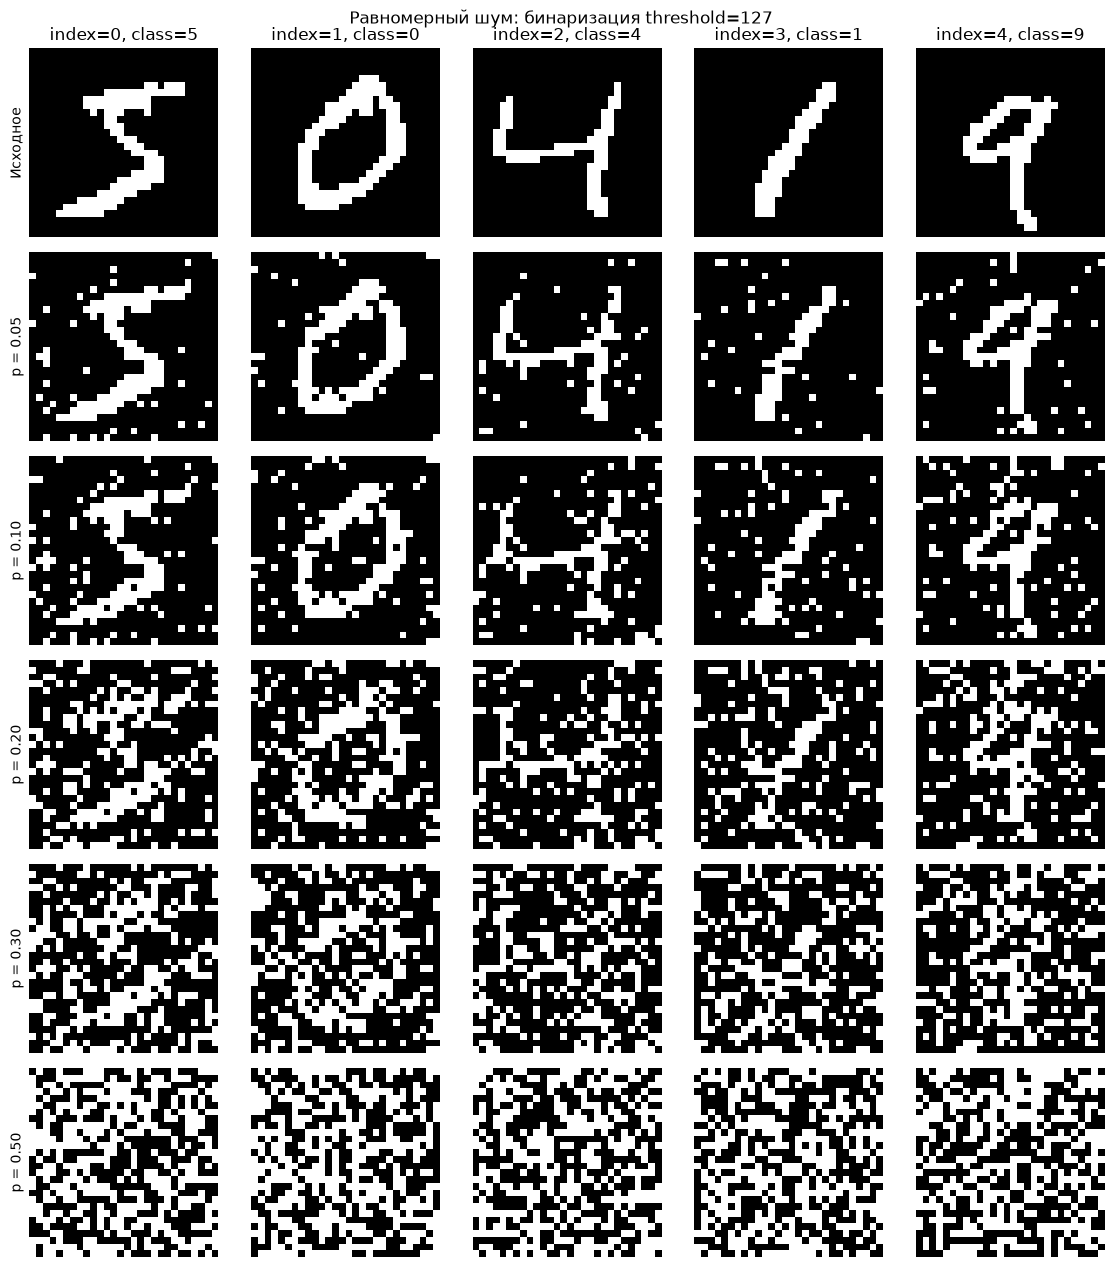

In [156]:
uniform_probabilities = [0.05, 0.10, 0.20, 0.30, 0.50]
simple_binary_example_images = two_level_binarize(
    example_images, threshold=127, low=0.0, high=1.0
)

uniform_gray_figure = plot_uniform_noise_comparison(
    X_gray_float,
    y,
    indices=example_indices,
    probabilities=uniform_probabilities,
    delta=0.75,
    seed=42,
)
uniform_gray_figure.suptitle(
    "Равномерный шум: серые изображения, delta=0.75", y=1.002
)
plt.show()

uniform_binary_figure = plot_uniform_noise_comparison(
    simple_binary_example_images,
    example_labels,
    indices=range(len(example_indices)),
    probabilities=uniform_probabilities,
    levels=(0.0, 1.0),
    seed=42,
)
uniform_binary_figure.suptitle(
    "Равномерный шум: бинаризация threshold=127", y=1.002
)
plt.show()


## Контурный неравномерный шум

Сначала для каждого пикселя вычисляется сила локального перепада яркости `g` от 0 до 1. Затем она превращается в индивидуальную вероятность изменения пикселя:

`p = p_min + (p_max - p_min) * g ** gamma`

- `p_min` задаёт шум на ровных участках;
- `p_max` задаёт шум на самом сильном контуре;
- при `gamma > 1` шум сильнее концентрируется непосредственно около границ цифры.


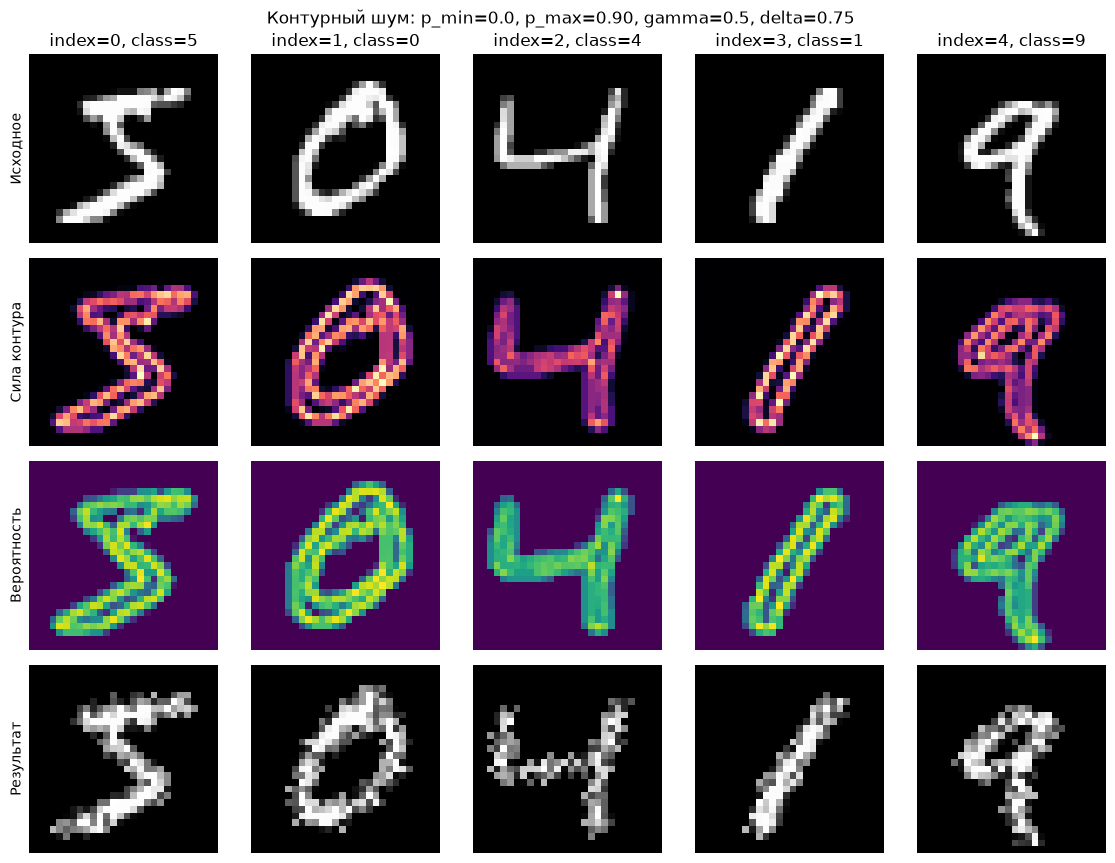

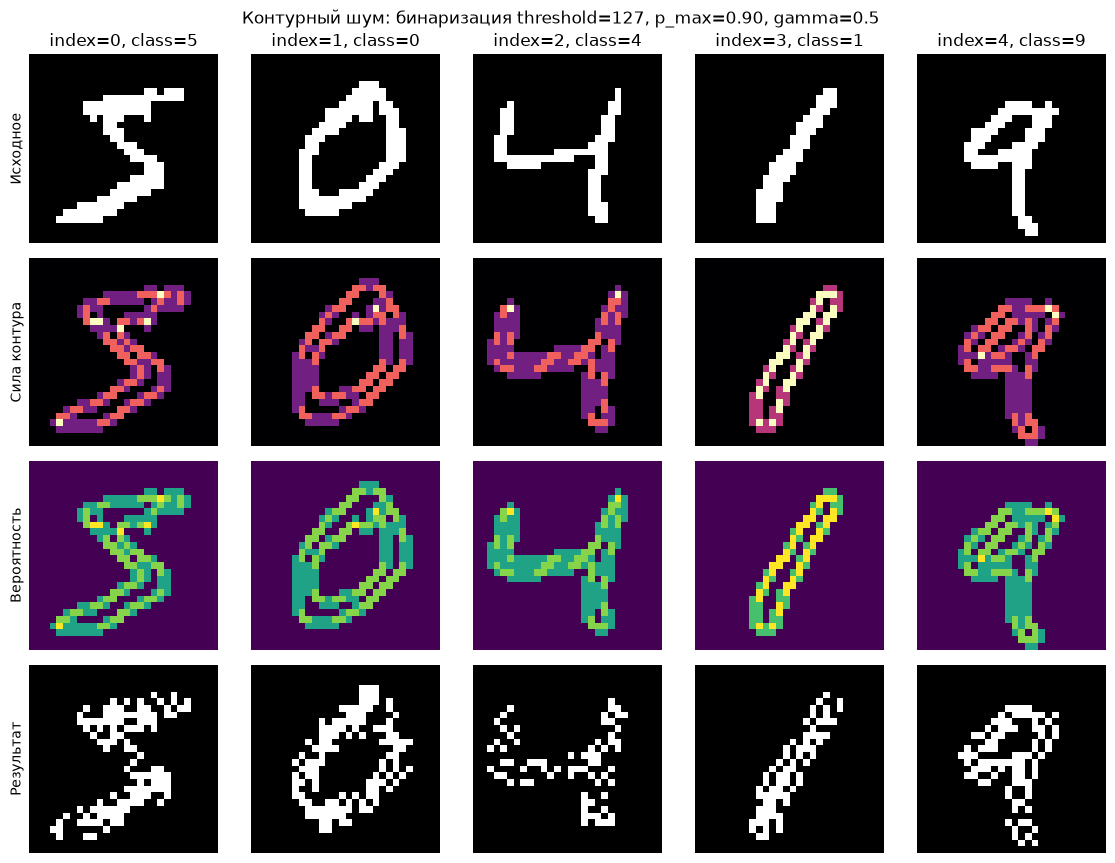

In [157]:
contour_gray_figure = plot_contour_noise_examples(
    X_gray_float,
    y,
    indices=example_indices,
    p_min=0.0,
    p_max=0.90,
    gamma=0.5,
    delta=0.75,
    seed=42,
)
contour_gray_figure.suptitle(
    "Контурный шум: p_min=0.0, p_max=0.90, gamma=0.5, delta=0.75",
    y=1.01,
)
plt.show()

contour_binary_figure = plot_contour_noise_examples(
    simple_binary_example_images,
    example_labels,
    indices=range(len(example_indices)),
    p_min=0.0,
    p_max=0.90,
    gamma=0.5,
    levels=(0.0, 1.0),
    seed=42,
)
contour_binary_figure.suptitle(
    "Контурный шум: бинаризация threshold=127, p_max=0.90, gamma=0.5",
    y=1.01,
)
plt.show()

In [158]:
from scipy.stats import mode
from sklearn.neighbors import NearestNeighbors


def make_balanced_subset(images, labels, samples_per_class=1_000, seed=42):
    rng = np.random.default_rng(seed)
    selected_indices = np.concatenate([
        rng.choice(
            np.flatnonzero(labels == class_label),
            size=samples_per_class,
            replace=False,
        )
        for class_label in np.unique(labels)
    ])
    rng.shuffle(selected_indices)
    return (
        images[selected_indices],
        labels[selected_indices],
        selected_indices,
    )


def evaluate_leave_one_out_knn(
    images, labels, k_values, metric="euclidean", metric_params=None
):
    images = np.asarray(images, dtype=np.float32)
    labels = np.asarray(labels)
    k_values = sorted(set(k_values))
    features = images.reshape(len(images), -1)

    model = NearestNeighbors(
        n_neighbors=max(k_values),
        algorithm="brute",
        metric=metric,
        metric_params=metric_params,
        n_jobs=-1,
    )

    model.fit(features)

    neighbor_distances, neighbor_indices = model.kneighbors(
        X=None,
        return_distance=True,
    )
    predictions = {
        k: mode(
            labels[neighbor_indices[:, :k]],
            axis=1,
            keepdims=False,
        ).mode
        for k in k_values
    }
    return {
        "metric": metric,
        "sample_count": len(images),
        "predictions": predictions,
        "accuracy_percent": {
            k: float(np.mean(prediction == labels) * 100.0)
            for k, prediction in predictions.items()
        },
        "neighbor_distances": neighbor_distances,
        "neighbor_indices": neighbor_indices,
    }


### Leave-one-out KNN на сбалансированной части MNIST

Случайно выбираются ровно 1 000 изображений каждого класса. Все 10 000 объектов одновременно служат и исследуемой, и эталонной выборкой. При поиске соседей текущий объект исключается, поэтому он не может выбрать самого себя.


In [159]:
knn_k_values = [1, 3, 5, 7, 9]
balanced_gray_images, balanced_labels, balanced_indices = (
    make_balanced_subset(
        X_gray_float,
        y,
        samples_per_class=1_000,
        seed=42,
    )
)

gray_knn_result = evaluate_leave_one_out_knn(
    balanced_gray_images,
    balanced_labels,
    k_values=knn_k_values,
    metric="euclidean",
)
print("Количество объектов:", gray_knn_result["sample_count"])
print("Объектов по классам:", np.bincount(balanced_labels))
print("Точность, %:", gray_knn_result["accuracy_percent"])


Количество объектов: 10000
Объектов по классам: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Точность, %: {1: 95.23, 3: 95.30999999999999, 5: 95.12, 7: 94.87, 9: 94.55}


## Массовые эксперименты KNN

Ниже собран возобновляемый конвейер для 93 вариантов выборки: 31 базовое представление и три режима шума.


In [160]:
from pathlib import Path

import pandas as pd


EXPERIMENT_SEED = 42
EXPERIMENT_K_VALUES = (1, 3, 5, 7, 9)
EXPERIMENT_METRICS = (
    "euclidean",
    "squared_euclidean",
    "manhattan",
    "weighted_euclidean",
    "chebyshev",
)
FULL_SAMPLES_PER_CLASS = 1_000
UNIFORM_NOISE_PROBABILITY = 0.10
GRAY_NOISE_DELTA = 0.75
CONTOUR_NOISE_PARAMETERS = {
    "p_min": 0.0,
    "p_max": 0.90,
    "gamma": 0.5,
}
RESULTS_DIRECTORY = Path("results")
RESULTS_CSV_PATH = RESULTS_DIRECTORY / "knn_results.csv"
RESULTS_FIGURES_DIRECTORY = RESULTS_DIRECTORY / "figures"


In [161]:
def build_experiment_specs(configs):
    base_specs = [
        {
            "base_name": "gray",
            "threshold": None,
            "low": None,
            "high": None,
            "base_description": "Исходные серые изображения в диапазоне [0, 1].",
        }
    ]
    base_specs.extend(
        {
            "base_name": config["name"],
            "threshold": config["threshold"],
            "low": config["low"],
            "high": config["high"],
            "base_description": config["description"],
        }
        for config in configs
    )

    specs = []
    for base in base_specs:
        is_gray = base["base_name"] == "gray"
        noise_descriptions = {
            "none": "без шума",
            "uniform": (
                f"равномерный шум: p={UNIFORM_NOISE_PROBABILITY}, "
                + (f"delta={GRAY_NOISE_DELTA}" if is_gray else "low <-> high")
            ),
            "contour": (
                "контурный шум: p_min=0.0, p_max=0.9, gamma=0.5, "
                + (f"delta={GRAY_NOISE_DELTA}" if is_gray else "low <-> high")
            ),
        }

        for noise_type, noise_parameters in noise_descriptions.items():
            specs.append(
                {
                    **base,
                    "dataset_id": f"{base['base_name']}__{noise_type}",
                    "noise_type": noise_type,
                    "noise_parameters": noise_parameters,
                    "description": (
                        f"{base['base_description']} Помеха: {noise_parameters}."
                    ),
                }
            )

    return specs


def materialize_experiment_images(
    spec, raw_images, gray_images, seed=EXPERIMENT_SEED
):
    if len(raw_images) != len(gray_images):
        raise ValueError("raw_images and gray_images must have equal lengths")

    if spec["base_name"] == "gray":
        base_images = np.asarray(gray_images, dtype=np.float32)
        noise_kwargs = {"delta": GRAY_NOISE_DELTA}
    else:
        base_images = two_level_binarize(
            raw_images,
            threshold=spec["threshold"],
            low=spec["low"],
            high=spec["high"],
        )
        noise_kwargs = {"levels": (spec["low"], spec["high"])}

    if spec["noise_type"] == "none":
        result = base_images
    elif spec["noise_type"] == "uniform":
        result = add_uniform_noise(
            base_images,
            noise_probability=UNIFORM_NOISE_PROBABILITY,
            seed=seed,
            **noise_kwargs,
        )
    elif spec["noise_type"] == "contour":
        result = add_contour_noise(
            base_images,
            **CONTOUR_NOISE_PARAMETERS,
            seed=seed,
            **noise_kwargs,
        )
    else:
        raise ValueError(f"Unknown noise type: {spec['noise_type']}")

    return np.asarray(result, dtype=np.float32)


def make_spatial_weight_map(height=28, width=28):
    vertical = np.linspace(-1.0, 1.0, height, dtype=np.float32)[:, None]
    horizontal = np.linspace(-1.0, 1.0, width, dtype=np.float32)[None, :]
    weights = 1.0 + (1.0 - horizontal**2) * (1.0 - vertical**2)
    return weights.astype(np.float32, copy=False)


experiment_specs = build_experiment_specs(binarization_configs)
spatial_weight_map = make_spatial_weight_map()

assert len(experiment_specs) == 93
assert len({spec["dataset_id"] for spec in experiment_specs}) == 93
assert {spec["noise_type"] for spec in experiment_specs} == {
    "none", "uniform", "contour"
}
assert spatial_weight_map.shape == (28, 28)
assert float(spatial_weight_map.min()) == 1.0
assert spatial_weight_map[14, 14] > spatial_weight_map[0, 0]

print(f"Подготовлено вариантов: {len(experiment_specs)}")


Подготовлено вариантов: 93


In [162]:
def evaluate_experiment_metrics(
    images,
    labels,
    k_values=EXPERIMENT_K_VALUES,
    weight_map=None,
):
    images = np.asarray(images, dtype=np.float32)
    labels = np.asarray(labels)
    if weight_map is None:
        weight_map = make_spatial_weight_map(*images.shape[1:])
    weight_map = np.asarray(weight_map, dtype=np.float32)

    if images.ndim != 3 or weight_map.shape != images.shape[1:]:
        raise ValueError(
            "weight_map shape must match the spatial image shape"
        )

    accuracy_by_metric = {}
    for metric_name in ("euclidean", "manhattan", "chebyshev"):
        result = evaluate_leave_one_out_knn(
            images,
            labels,
            k_values=k_values,
            metric=metric_name,
        )
        accuracy_by_metric[metric_name] = {
            k: accuracy_percent / 100.0
            for k, accuracy_percent in result["accuracy_percent"].items()
        }
        del result

    accuracy_by_metric["squared_euclidean"] = dict(
        accuracy_by_metric["euclidean"]
    )

    weighted_images = (
        images * np.sqrt(weight_map, dtype=np.float32)[None, :, :]
    ).astype(np.float32, copy=False)
    weighted_result = evaluate_leave_one_out_knn(
        weighted_images,
        labels,
        k_values=k_values,
        metric="euclidean",
    )
    accuracy_by_metric["weighted_euclidean"] = {
        k: accuracy_percent / 100.0
        for k, accuracy_percent in weighted_result["accuracy_percent"].items()
    }
    del weighted_images, weighted_result

    return {
        metric_name: accuracy_by_metric[metric_name]
        for metric_name in EXPERIMENT_METRICS
    }


In [163]:
import textwrap

from matplotlib.ticker import PercentFormatter


RESULT_COLUMNS = (
    "dataset_id",
    "base_name",
    "threshold",
    "low",
    "high",
    "noise_type",
    "noise_parameters",
    "metric",
    "k",
    "accuracy",
    "sample_count",
    "seed",
)


def build_result_rows(spec, accuracy_by_metric, sample_count, seed):
    records = []
    for metric_name in EXPERIMENT_METRICS:
        for k in EXPERIMENT_K_VALUES:
            records.append(
                {
                    "dataset_id": spec["dataset_id"],
                    "base_name": spec["base_name"],
                    "threshold": spec["threshold"],
                    "low": spec["low"],
                    "high": spec["high"],
                    "noise_type": spec["noise_type"],
                    "noise_parameters": spec["noise_parameters"],
                    "metric": metric_name,
                    "k": k,
                    "accuracy": float(accuracy_by_metric[metric_name][k]),
                    "sample_count": sample_count,
                    "seed": seed,
                }
            )

    rows = pd.DataFrame.from_records(records, columns=RESULT_COLUMNS)
    if len(rows) != len(EXPERIMENT_METRICS) * len(EXPERIMENT_K_VALUES):
        raise RuntimeError("Unexpected number of metric rows")
    if rows.duplicated(["metric", "k"]).any():
        raise RuntimeError("Duplicate metric/k rows")
    return rows


def load_results(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return pd.DataFrame(columns=RESULT_COLUMNS)

    results = pd.read_csv(csv_path)
    missing_columns = set(RESULT_COLUMNS) - set(results.columns)
    if missing_columns:
        raise ValueError(
            f"Results CSV misses columns: {sorted(missing_columns)}"
        )
    return results.loc[:, RESULT_COLUMNS]


def dataset_is_complete(
    results,
    dataset_id,
    figure_path,
    metrics=EXPERIMENT_METRICS,
    k_values=EXPERIMENT_K_VALUES,
    sample_count=None,
    seed=None,
):
    dataset_rows = results.loc[results["dataset_id"] == dataset_id]
    expected_pairs = {(metric, k) for metric in metrics for k in k_values}
    actual_pairs = set(
        zip(dataset_rows["metric"], dataset_rows["k"].astype(int))
    )
    metadata_matches = (
        (sample_count is None or dataset_rows["sample_count"].eq(sample_count).all())
        and (seed is None or dataset_rows["seed"].eq(seed).all())
    )
    return (
        len(dataset_rows) == len(expected_pairs)
        and actual_pairs == expected_pairs
        and metadata_matches
        and Path(figure_path).is_file()
    )


def save_dataset_results(results, new_rows, csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if new_rows["dataset_id"].nunique() != 1:
        raise ValueError("new_rows must contain exactly one dataset_id")

    dataset_id = new_rows["dataset_id"].iloc[0]
    preserved = results.loc[results["dataset_id"] != dataset_id]
    updated = pd.concat([preserved, new_rows], ignore_index=True)
    updated = updated.loc[:, RESULT_COLUMNS]

    temporary_path = csv_path.with_suffix(csv_path.suffix + ".tmp")
    updated.to_csv(temporary_path, index=False)
    temporary_path.replace(csv_path)
    return updated


def plot_experiment_report(
    images,
    labels,
    sample_indices,
    spec,
    accuracy_by_metric,
    k_values=EXPERIMENT_K_VALUES,
):
    sample_indices = np.asarray(sample_indices)
    if len(sample_indices) != 5:
        raise ValueError("Exactly five sample indices are required")

    figure = plt.figure(figsize=(15, 8), constrained_layout=True)
    grid = figure.add_gridspec(2, 5, height_ratios=(1.0, 1.35))

    for column, sample_index in enumerate(sample_indices):
        axis = figure.add_subplot(grid[0, column])
        axis.imshow(images[sample_index], cmap="gray", vmin=0.0, vmax=1.0)
        axis.set_title(
            f"index={sample_index}, class={labels[sample_index]}"
        )
        axis.axis("off")

    accuracy_axis = figure.add_subplot(grid[1, :])
    line_styles = {
        "euclidean": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
        "squared_euclidean": {"color": "tab:orange", "linestyle": "--", "marker": "x"},
        "manhattan": {"color": "tab:green", "linestyle": "-", "marker": "s"},
        "weighted_euclidean": {"color": "tab:red", "linestyle": "-", "marker": "^"},
        "chebyshev": {"color": "tab:purple", "linestyle": "-", "marker": "D"},
    }
    for metric_name in EXPERIMENT_METRICS:
        accuracy_axis.plot(
            k_values,
            [accuracy_by_metric[metric_name][k] for k in k_values],
            label=metric_name,
            linewidth=2.0,
            markersize=6,
            **line_styles[metric_name],
        )

    accuracy_axis.set_xlabel("k")
    accuracy_axis.set_ylabel("Accuracy")
    accuracy_axis.set_xticks(k_values)
    all_accuracies = [
        accuracy_by_metric[metric_name][k]
        for metric_name in EXPERIMENT_METRICS
        for k in k_values
    ]
    accuracy_axis.set_ylim(
        max(0.0, min(all_accuracies) - 0.05),
        min(1.0, max(all_accuracies) + 0.05),
    )
    accuracy_axis.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    accuracy_axis.grid(True, alpha=0.3)
    accuracy_axis.legend(ncol=3)
    accuracy_axis.set_title("Leave-one-out KNN")

    wrapped_description = textwrap.fill(spec["description"], width=115)
    figure.suptitle(
        f"{spec['dataset_id']}\n{wrapped_description}",
        fontsize=13,
    )
    return figure


### Возобновляемый запуск

Каждый вариант после расчёта сразу добавляется в CSV и сохраняется как PNG. Повторный запуск пропускает уже готовые варианты.


In [164]:
def run_knn_experiments(
    raw_images,
    gray_images,
    labels,
    configs,
    samples_per_class,
    output_dir,
    seed=EXPERIMENT_SEED,
    max_datasets=None,
    show_current=False,
):
    output_dir = Path(output_dir)
    csv_path = output_dir / "knn_results.csv"
    figures_directory = output_dir / "figures"
    figures_directory.mkdir(parents=True, exist_ok=True)

    raw_subset, subset_labels, source_indices = make_balanced_subset(
        raw_images,
        labels,
        samples_per_class=samples_per_class,
        seed=seed,
    )
    gray_subset = np.asarray(gray_images[source_indices], dtype=np.float32)

    preview_rng = np.random.default_rng(seed)
    preview_indices = np.sort(
        preview_rng.choice(len(subset_labels), size=5, replace=False)
    )
    weight_map = make_spatial_weight_map(*raw_subset.shape[1:])

    specs = build_experiment_specs(configs)
    if max_datasets is not None:
        if max_datasets < 0:
            raise ValueError("max_datasets must be non-negative or None")
        specs = specs[:max_datasets]

    results = load_results(csv_path)
    total = len(specs)
    for position, spec in enumerate(specs, start=1):
        figure_path = figures_directory / f"{spec['dataset_id']}.png"
        if dataset_is_complete(
            results,
            spec["dataset_id"],
            figure_path,
            sample_count=len(subset_labels),
            seed=seed,
        ):
            print(f"[{position}/{total}] готово: {spec['dataset_id']}")
            continue

        print(f"[{position}/{total}] расчёт: {spec['dataset_id']}")
        current_images = materialize_experiment_images(
            spec, raw_subset, gray_subset, seed=seed
        )
        accuracy_by_metric = evaluate_experiment_metrics(
            current_images,
            subset_labels,
            k_values=EXPERIMENT_K_VALUES,
            weight_map=weight_map,
        )

        figure = plot_experiment_report(
            current_images,
            subset_labels,
            preview_indices,
            spec,
            accuracy_by_metric,
            k_values=EXPERIMENT_K_VALUES,
        )
        try:
            figure.savefig(figure_path, dpi=140, bbox_inches="tight")
            if show_current:
                from IPython.display import display

                display(figure)
        finally:
            plt.close(figure)

        new_rows = build_result_rows(
            spec,
            accuracy_by_metric,
            sample_count=len(subset_labels),
            seed=seed,
        )
        results = save_dataset_results(results, new_rows, csv_path)
        print(f"    сохранено: {figure_path}")

        del current_images, accuracy_by_metric, new_rows, figure

    return results


### Полный запуск

Эта ячейка запускает долгий расчёт 93 вариантов на 10 000 объектах. По умолчанию он отключён: измени `RUN_FULL_EXPERIMENT` на `True` и запусти ячейку. При повторном запуске готовые варианты будут пропущены.


In [165]:
RUN_FULL_EXPERIMENT = False

if RUN_FULL_EXPERIMENT:
    full_results = run_knn_experiments(
        X,
        X_gray_float,
        y,
        binarization_configs,
        samples_per_class=FULL_SAMPLES_PER_CLASS,
        output_dir=RESULTS_DIRECTORY,
        seed=EXPERIMENT_SEED,
        max_datasets=None,
        show_current=False,
    )


# Задание №5: обнаружение выбросов с помощью KNN и ODIN

Искусственно созданное необычное изображение считаем выбросом типа 0. Если KNN не обнаружил известный выброс типа 0, это выброс типа 1 для выбранного `k`. Если ODIN не обнаружил его, это выброс типа 2 для выбранных `k` и `T`.

Эксперименты выполняются на серых изображениях с обычным евклидовым расстоянием. Генерируются spatial hybrid и mixup, после чего отдельно исследуются выборки с каждым типом и их смесью.

In [166]:
from sklearn.metrics import average_precision_score, precision_recall_curve


OUTLIER_SEED = 42
OUTLIER_K_VALUES = (1, 3, 5, 7, 9)
OUTLIERS_PER_CLASS = 100
MIXUP_ALPHA = 0.5
OUTLIER_RESULTS_DIRECTORY = Path("results/outliers")
OUTLIER_POOLS_PATH = OUTLIER_RESULTS_DIRECTORY / "type0_pools.npz"
OUTLIER_RESULTS_CSV_PATH = OUTLIER_RESULTS_DIRECTORY / "detection_results.csv"
OUTLIER_CACHE_DIRECTORY = OUTLIER_RESULTS_DIRECTORY / "cache"
OUTLIER_FIGURES_DIRECTORY = OUTLIER_RESULTS_DIRECTORY / "figures"

In [167]:
def make_type0_parent_pairs(
    images, labels, pairs_per_class=100, seed=42
):
    images = np.asarray(images)
    labels = np.asarray(labels)
    if len(images) != len(labels):
        raise ValueError("images and labels must have equal lengths")
    if pairs_per_class <= 0:
        raise ValueError("pairs_per_class must be positive")

    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    primary_indices = np.concatenate([
        rng.choice(
            np.flatnonzero(labels == class_label),
            size=pairs_per_class,
            replace=False,
        )
        for class_label in classes
    ])
    rng.shuffle(primary_indices)
    primary_classes = labels[primary_indices]

    secondary_indices = np.asarray([
        rng.choice(np.flatnonzero(labels != primary_class))
        for primary_class in primary_classes
    ])
    secondary_classes = labels[secondary_indices]

    return {
        "pair_id": np.arange(len(primary_indices), dtype=np.int32),
        "primary_index": primary_indices.astype(np.int32),
        "primary_class": primary_classes.astype(np.int64),
        "secondary_index": secondary_indices.astype(np.int32),
        "secondary_class": secondary_classes.astype(np.int64),
    }


def make_spatial_hybrid_pool(images, pairs, seed=42):
    images = np.asarray(images, dtype=np.float32)
    if images.ndim != 3:
        raise ValueError("images must have shape (N, height, width)")

    count = len(pairs["pair_id"])
    height, width = images.shape[1:]
    rng = np.random.default_rng(seed)
    orientation = rng.integers(0, 2, size=count, dtype=np.int8)
    split = rng.integers(11, 18, size=count, dtype=np.int16)
    amplitude = rng.integers(2, 6, size=count).astype(np.float32)
    frequency = rng.uniform(0.75, 1.75, size=count).astype(np.float32)
    phase = rng.uniform(0.0, 2.0 * np.pi, size=count).astype(np.float32)

    primary_images = images[pairs["primary_index"]]
    secondary_images = images[pairs["secondary_index"]]
    hybrid_images = np.empty_like(primary_images, dtype=np.float32)
    row_coordinates = np.arange(height, dtype=np.float32)
    column_coordinates = np.arange(width, dtype=np.float32)

    for index in range(count):
        if orientation[index] == 0:
            boundary = split[index] + amplitude[index] * np.sin(
                2.0 * np.pi * frequency[index]
                * row_coordinates / max(height - 1, 1)
                + phase[index]
            )
            mask = column_coordinates[None, :] <= boundary[:, None]
        else:
            boundary = split[index] + amplitude[index] * np.sin(
                2.0 * np.pi * frequency[index]
                * column_coordinates / max(width - 1, 1)
                + phase[index]
            )
            mask = row_coordinates[:, None] <= boundary[None, :]

        hybrid_images[index] = np.where(
            mask, primary_images[index], secondary_images[index]
        )

    return {
        **{name: np.asarray(values).copy() for name, values in pairs.items()},
        "images": hybrid_images.astype(np.float32, copy=False),
        "labels": np.asarray(pairs["primary_class"], dtype=np.int64),
        "kind": np.full(count, "spatial", dtype="<U7"),
        "orientation": orientation,
        "split": split,
        "amplitude": amplitude,
        "frequency": frequency,
        "phase": phase,
    }


def make_mixup_pool(images, pairs, alpha=0.5):
    images = np.asarray(images, dtype=np.float32)
    if not 0.0 < alpha < 1.0:
        raise ValueError("alpha must be between 0 and 1")

    primary_images = images[pairs["primary_index"]]
    secondary_images = images[pairs["secondary_index"]]
    mixed_images = (
        alpha * primary_images + (1.0 - alpha) * secondary_images
    ).astype(np.float32)
    count = len(mixed_images)

    return {
        **{name: np.asarray(values).copy() for name, values in pairs.items()},
        "images": mixed_images,
        "labels": np.asarray(pairs["primary_class"], dtype=np.int64),
        "kind": np.full(count, "mixup", dtype="<U7"),
        "alpha": np.full(count, alpha, dtype=np.float32),
    }


def save_type0_pools(spatial_pool, mixup_pool, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {}
    for prefix, pool in (("spatial", spatial_pool), ("mixup", mixup_pool)):
        for name, values in pool.items():
            payload[f"{prefix}_{name}"] = np.asarray(values)
    np.savez_compressed(output_path, **payload)


def plot_type0_generation_examples(
    clean_images, spatial_pool, mixup_pool, pair_positions
):
    pair_positions = np.asarray(pair_positions, dtype=int)
    figure, axes = plt.subplots(
        len(pair_positions), 4,
        figsize=(9.5, 2.25 * len(pair_positions)),
        squeeze=False,
    )
    column_names = ("Первый родитель", "Второй родитель", "Spatial", "Mixup")

    for row, position in enumerate(pair_positions):
        primary_index = spatial_pool["primary_index"][position]
        secondary_index = spatial_pool["secondary_index"][position]
        images = (
            clean_images[primary_index],
            clean_images[secondary_index],
            spatial_pool["images"][position],
            mixup_pool["images"][position],
        )
        classes = (
            spatial_pool["primary_class"][position],
            spatial_pool["secondary_class"][position],
            spatial_pool["labels"][position],
            mixup_pool["labels"][position],
        )

        for column, (image, class_label) in enumerate(zip(images, classes)):
            axis = axes[row, column]
            axis.imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
            if row == 0:
                axis.set_title(column_names[column])
            axis.set_xlabel(f"метка={class_label}")
            axis.set_xticks([])
            axis.set_yticks([])

    figure.suptitle("Генерация выбросов типа 0", fontsize=14)
    figure.tight_layout()
    return figure

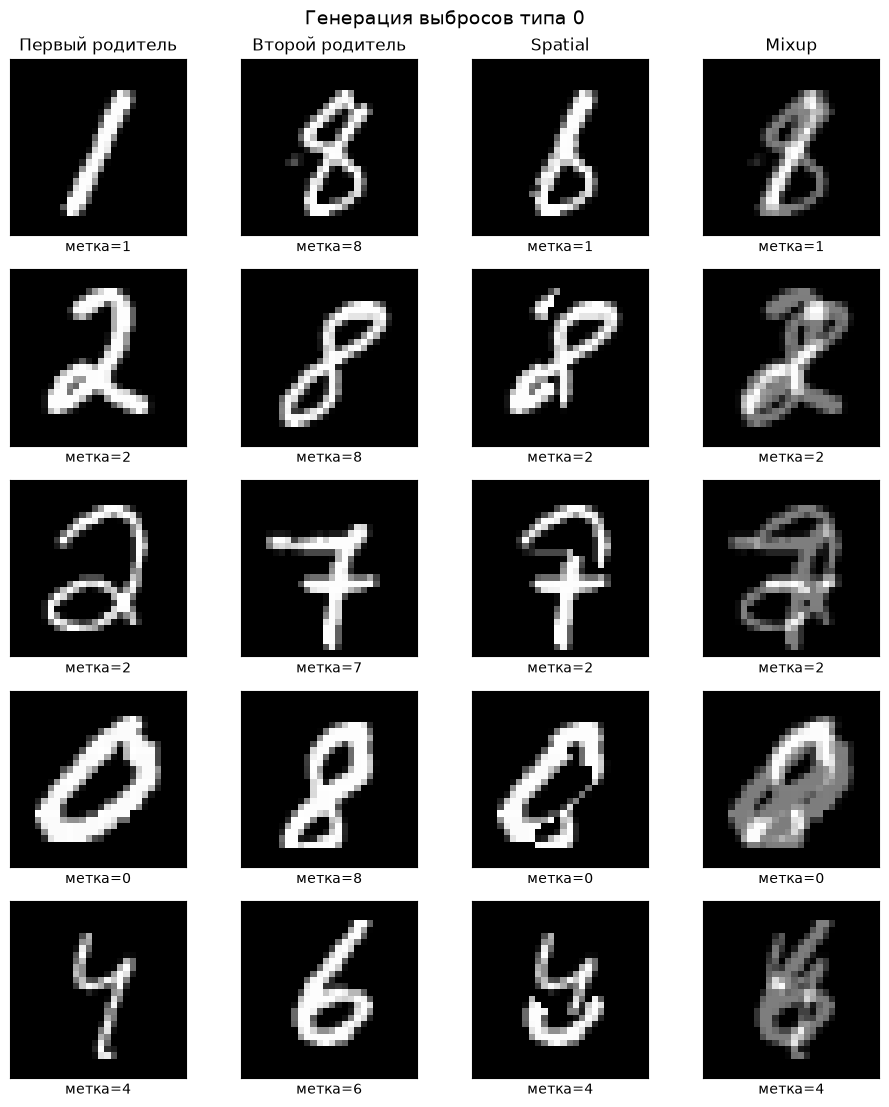

In [168]:
outlier_clean_images, outlier_clean_labels, outlier_clean_source_indices = (
    make_balanced_subset(
        X_gray_float,
        y,
        samples_per_class=1_000,
        seed=OUTLIER_SEED,
    )
)
type0_parent_pairs = make_type0_parent_pairs(
    outlier_clean_images,
    outlier_clean_labels,
    pairs_per_class=OUTLIERS_PER_CLASS,
    seed=OUTLIER_SEED,
)
spatial_pool = make_spatial_hybrid_pool(
    outlier_clean_images, type0_parent_pairs, seed=OUTLIER_SEED
)
mixup_pool = make_mixup_pool(
    outlier_clean_images, type0_parent_pairs, alpha=MIXUP_ALPHA
)

assert spatial_pool["images"].shape == mixup_pool["images"].shape == (1000, 28, 28)
assert spatial_pool["images"].dtype == mixup_pool["images"].dtype == np.float32
assert np.all(type0_parent_pairs["primary_class"] != type0_parent_pairs["secondary_class"])
assert np.array_equal(np.bincount(spatial_pool["labels"]), np.full(10, 100))
assert np.array_equal(spatial_pool["labels"], mixup_pool["labels"])
assert np.isfinite(spatial_pool["images"]).all()
assert np.isfinite(mixup_pool["images"]).all()
assert 0.0 <= spatial_pool["images"].min() <= spatial_pool["images"].max() <= 1.0
assert 0.0 <= mixup_pool["images"].min() <= mixup_pool["images"].max() <= 1.0

save_type0_pools(spatial_pool, mixup_pool, OUTLIER_POOLS_PATH)
OUTLIER_FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
type0_preview_positions = np.arange(5)
type0_preview_figure = plot_type0_generation_examples(
    outlier_clean_images,
    spatial_pool,
    mixup_pool,
    type0_preview_positions,
)
type0_preview_figure.savefig(
    OUTLIER_FIGURES_DIRECTORY / "generated_outliers.png",
    dpi=140,
    bbox_inches="tight",
)
plt.show()

## Экспериментальные выборки и общий граф соседей

Во всех трёх экспериментах используются те же 10 000 чистых изображений. К ним добавляются 1 000 spatial-выбросов, 1 000 mixup-выбросов или сбалансированная смесь `500 + 500`. Один поиск девяти соседей затем используется обоими детекторами.

In [169]:
def build_outlier_experiment(
    name, clean_images, clean_labels, spatial_pool, mixup_pool, seed=42
):
    if name not in {"spatial", "mixup", "combined"}:
        raise ValueError("name must be spatial, mixup, or combined")

    clean_images = np.asarray(clean_images, dtype=np.float32)
    clean_labels = np.asarray(clean_labels, dtype=np.int64)
    if len(clean_images) != len(clean_labels):
        raise ValueError("clean_images and clean_labels must have equal lengths")

    if name == "spatial":
        spatial_positions = np.arange(len(spatial_pool["images"]))
        mixup_positions = np.empty(0, dtype=int)
    elif name == "mixup":
        spatial_positions = np.empty(0, dtype=int)
        mixup_positions = np.arange(len(mixup_pool["images"]))
    else:
        rng = np.random.default_rng(seed)
        spatial_parts = []
        mixup_parts = []
        for class_label in np.unique(spatial_pool["labels"]):
            class_positions = np.flatnonzero(
                spatial_pool["labels"] == class_label
            )
            if len(class_positions) % 2 != 0:
                raise ValueError("each class pool must have an even size")
            class_positions = rng.permutation(class_positions)
            half = len(class_positions) // 2
            spatial_parts.append(class_positions[:half])
            mixup_parts.append(class_positions[half:])
        spatial_positions = np.concatenate(spatial_parts)
        mixup_positions = np.concatenate(mixup_parts)

    generated_images = []
    generated_labels = []
    generated_kinds = []
    generated_pair_ids = []
    generated_source_positions = []
    generated_primary_indices = []
    generated_secondary_indices = []

    for pool, positions in (
        (spatial_pool, spatial_positions),
        (mixup_pool, mixup_positions),
    ):
        if len(positions) == 0:
            continue
        generated_images.append(pool["images"][positions])
        generated_labels.append(pool["labels"][positions])
        generated_kinds.append(pool["kind"][positions])
        generated_pair_ids.append(pool["pair_id"][positions])
        generated_source_positions.append(positions.astype(np.int32))
        generated_primary_indices.append(pool["primary_index"][positions])
        generated_secondary_indices.append(pool["secondary_index"][positions])

    generated_images = np.concatenate(generated_images, axis=0)
    generated_labels = np.concatenate(generated_labels)
    generated_kinds = np.concatenate(generated_kinds)
    generated_pair_ids = np.concatenate(generated_pair_ids).astype(np.int32)
    generated_source_positions = np.concatenate(
        generated_source_positions
    ).astype(np.int32)
    generated_primary_indices = np.concatenate(
        generated_primary_indices
    ).astype(np.int32)
    generated_secondary_indices = np.concatenate(
        generated_secondary_indices
    ).astype(np.int32)

    clean_count = len(clean_images)
    generated_count = len(generated_images)
    return {
        "name": name,
        "seed": seed,
        "images": np.concatenate(
            [clean_images, generated_images], axis=0
        ).astype(np.float32, copy=False),
        "labels": np.concatenate(
            [clean_labels, generated_labels]
        ).astype(np.int64, copy=False),
        "is_type0": np.concatenate([
            np.zeros(clean_count, dtype=bool),
            np.ones(generated_count, dtype=bool),
        ]),
        "outlier_kind": np.concatenate([
            np.full(clean_count, "clean", dtype="<U7"),
            generated_kinds.astype("<U7"),
        ]),
        "pair_id": np.concatenate([
            np.full(clean_count, -1, dtype=np.int32),
            generated_pair_ids,
        ]),
        "source_position": np.concatenate([
            np.arange(clean_count, dtype=np.int32),
            generated_source_positions,
        ]),
        "primary_index": np.concatenate([
            np.full(clean_count, -1, dtype=np.int32),
            generated_primary_indices,
        ]),
        "secondary_index": np.concatenate([
            np.full(clean_count, -1, dtype=np.int32),
            generated_secondary_indices,
        ]),
    }


def find_leave_one_out_neighbors(images, max_k=9):
    images = np.asarray(images, dtype=np.float32)
    if images.ndim != 3:
        raise ValueError("images must have shape (N, height, width)")
    if not 1 <= max_k < len(images):
        raise ValueError("max_k must be positive and smaller than sample size")

    features = images.reshape(len(images), -1)
    model = NearestNeighbors(
        n_neighbors=max_k,
        algorithm="brute",
        metric="euclidean",
        n_jobs=-1,
    )
    model.fit(features)
    distances, indices = model.kneighbors(X=None, return_distance=True)
    return {
        "indices": indices.astype(np.int32, copy=False),
        "distances": distances.astype(np.float32, copy=False),
    }


def load_neighbor_cache(
    cache_path, experiment_name, sample_count, max_k, seed
):
    cache_path = Path(cache_path)
    if not cache_path.is_file():
        return None

    try:
        with np.load(cache_path, allow_pickle=False) as data:
            metadata_matches = (
                str(data["experiment_name"].item()) == experiment_name
                and int(data["sample_count"].item()) == sample_count
                and int(data["max_k"].item()) == max_k
                and int(data["seed"].item()) == seed
            )
            indices = data["indices"]
            distances = data["distances"]
    except (OSError, ValueError, KeyError):
        return None

    expected_shape = (sample_count, max_k)
    if (
        not metadata_matches
        or indices.shape != expected_shape
        or distances.shape != expected_shape
        or np.any(indices < 0)
        or np.any(indices >= sample_count)
        or np.any(indices == np.arange(sample_count)[:, None])
        or not np.isfinite(distances).all()
    ):
        return None

    return {
        "indices": indices.astype(np.int32, copy=False),
        "distances": distances.astype(np.float32, copy=False),
    }


def save_neighbor_cache(
    cache_path, experiment_name, neighbors, sample_count, max_k, seed
):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = cache_path.with_name(
        f"{cache_path.stem}.tmp.npz"
    )
    np.savez_compressed(
        temporary_path,
        experiment_name=np.asarray(experiment_name),
        sample_count=np.asarray(sample_count),
        max_k=np.asarray(max_k),
        seed=np.asarray(seed),
        indices=np.asarray(neighbors["indices"], dtype=np.int32),
        distances=np.asarray(neighbors["distances"], dtype=np.float32),
    )
    temporary_path.replace(cache_path)

## KNN и ODIN

KNN считает объект выбросом, если большинство его соседей предсказывает класс, отличный от сохранённой метки. ODIN не использует метки: объект считается выбросом при `indegree <= T`. Для каждого `k` проверяются все целые пороги от нуля до максимальной входящей степени.

In [170]:
def binary_detection_metrics(is_outlier, detected):
    is_outlier = np.asarray(is_outlier, dtype=bool)
    detected = np.asarray(detected, dtype=bool)
    if (
        is_outlier.ndim != 1
        or detected.ndim != 1
        or is_outlier.shape != detected.shape
    ):
        raise ValueError("is_outlier and detected must be equal 1D arrays")

    tp = int(np.sum(is_outlier & detected))
    fp = int(np.sum(~is_outlier & detected))
    tn = int(np.sum(~is_outlier & ~detected))
    fn = int(np.sum(is_outlier & ~detected))

    def safe_divide(numerator, denominator):
        return float(numerator / denominator) if denominator else 0.0

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2.0 * precision * recall, precision + recall)
    return {
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": safe_divide(fp, fp + tn),
        "detected_count": tp + fp,
        "missed_count": fn,
        "evaluated_count": len(is_outlier),
        "type0_count": int(np.sum(is_outlier)),
    }


def make_evaluation_subsets(outlier_kind):
    outlier_kind = np.asarray(outlier_kind)
    if outlier_kind.ndim != 1:
        raise ValueError("outlier_kind must be one-dimensional")

    subsets = {"all": np.ones(len(outlier_kind), dtype=bool)}
    unique_kinds = set(np.unique(outlier_kind))
    if {"spatial", "mixup"}.issubset(unique_kinds):
        subsets["spatial"] = (
            (outlier_kind == "clean") | (outlier_kind == "spatial")
        )
        subsets["mixup"] = (
            (outlier_kind == "clean") | (outlier_kind == "mixup")
        )
    return subsets


def evaluate_knn_detector(labels, outlier_kind, neighbor_indices, k_values):
    labels = np.asarray(labels)
    outlier_kind = np.asarray(outlier_kind)
    neighbor_indices = np.asarray(neighbor_indices)
    if len(labels) != len(outlier_kind) or len(labels) != len(neighbor_indices):
        raise ValueError("labels, outlier_kind and neighbors must align")

    is_type0 = outlier_kind != "clean"
    subsets = make_evaluation_subsets(outlier_kind)
    rows = []
    details = {}

    for k in sorted(set(k_values)):
        if not 1 <= k <= neighbor_indices.shape[1]:
            raise ValueError("every k must fit the neighbor matrix")
        predictions = mode(
            labels[neighbor_indices[:, :k]],
            axis=1,
            keepdims=False,
        ).mode
        detected = predictions != labels
        details[k] = {
            "predictions": predictions,
            "detected": detected,
            "is_type1": is_type0 & ~detected,
        }

        for evaluation_kind, subset in subsets.items():
            rows.append({
                "evaluation_kind": evaluation_kind,
                "detector": "knn",
                "k": k,
                "threshold": np.nan,
                "average_precision": np.nan,
                **binary_detection_metrics(
                    is_type0[subset], detected[subset]
                ),
            })

    return pd.DataFrame.from_records(rows), details


def odin_indegree(neighbor_indices, k, sample_count):
    neighbor_indices = np.asarray(neighbor_indices)
    if neighbor_indices.shape[0] != sample_count:
        raise ValueError("neighbor row count must equal sample_count")
    if not 1 <= k <= neighbor_indices.shape[1]:
        raise ValueError("k must fit the neighbor matrix")

    indegree = np.bincount(
        neighbor_indices[:, :k].ravel(),
        minlength=sample_count,
    ).astype(np.int32)
    if int(indegree.sum()) != sample_count * k:
        raise RuntimeError("indegree sum must equal the edge count")
    return indegree


def evaluate_odin_detector(outlier_kind, neighbor_indices, k_values):
    outlier_kind = np.asarray(outlier_kind)
    neighbor_indices = np.asarray(neighbor_indices)
    if len(outlier_kind) != len(neighbor_indices):
        raise ValueError("outlier_kind and neighbors must align")

    is_type0 = outlier_kind != "clean"
    subsets = make_evaluation_subsets(outlier_kind)
    metric_rows = []
    curve_rows = []
    details = {"indegree": {}, "average_precision": {}}

    for k in sorted(set(k_values)):
        indegree = odin_indegree(neighbor_indices, k, len(outlier_kind))
        details["indegree"][k] = indegree

        for evaluation_kind, subset in subsets.items():
            truth = is_type0[subset]
            scores = -indegree[subset].astype(np.float64)
            average_precision = float(
                average_precision_score(truth, scores)
            )
            details["average_precision"][(k, evaluation_kind)] = (
                average_precision
            )
            precision_values, recall_values, score_thresholds = (
                precision_recall_curve(truth, scores)
            )
            for point_index, (precision_value, recall_value) in enumerate(
                zip(precision_values, recall_values)
            ):
                curve_rows.append({
                    "evaluation_kind": evaluation_kind,
                    "k": k,
                    "precision": float(precision_value),
                    "recall": float(recall_value),
                    "score_threshold": (
                        float(score_thresholds[point_index])
                        if point_index < len(score_thresholds)
                        else np.nan
                    ),
                    "average_precision": average_precision,
                    "outlier_fraction": float(np.mean(truth)),
                })

        for threshold in range(int(indegree.max()) + 1):
            detected = indegree <= threshold
            for evaluation_kind, subset in subsets.items():
                metric_rows.append({
                    "evaluation_kind": evaluation_kind,
                    "detector": "odin",
                    "k": k,
                    "threshold": threshold,
                    "average_precision": details["average_precision"][
                        (k, evaluation_kind)
                    ],
                    **binary_detection_metrics(
                        is_type0[subset], detected[subset]
                    ),
                })

    return (
        pd.DataFrame.from_records(metric_rows),
        details,
        pd.DataFrame.from_records(curve_rows),
    )


def evaluate_outlier_experiment(
    experiment, neighbors, k_values=(1, 3, 5, 7, 9)
):
    knn_rows, knn_details = evaluate_knn_detector(
        experiment["labels"],
        experiment["outlier_kind"],
        neighbors["indices"],
        k_values,
    )
    odin_rows, odin_details, curve_rows = evaluate_odin_detector(
        experiment["outlier_kind"],
        neighbors["indices"],
        k_values,
    )

    result_rows = pd.concat([knn_rows, odin_rows], ignore_index=True)
    result_rows.insert(0, "experiment", experiment["name"])
    result_rows["seed"] = experiment["seed"]
    result_rows["sample_count"] = len(experiment["images"])
    curve_rows.insert(0, "experiment", experiment["name"])

    all_knn = result_rows.loc[
        (result_rows["detector"] == "knn")
        & (result_rows["evaluation_kind"] == "all")
    ].sort_values(["f1", "k"], ascending=[False, True])
    all_odin = result_rows.loc[
        (result_rows["detector"] == "odin")
        & (result_rows["evaluation_kind"] == "all")
    ].sort_values(
        ["f1", "threshold", "k"],
        ascending=[False, True, True],
    )
    best_knn = all_knn.iloc[0].to_dict()
    best_odin = all_odin.iloc[0].to_dict()
    best_knn_k = int(best_knn["k"])
    best_odin_k = int(best_odin["k"])
    best_odin_threshold = int(best_odin["threshold"])
    best_odin_detected = (
        odin_details["indegree"][best_odin_k] <= best_odin_threshold
    )

    return {
        "results": result_rows,
        "curves": curve_rows,
        "best_knn": best_knn,
        "best_odin": best_odin,
        "knn_details": knn_details,
        "odin_details": odin_details,
        "best_knn_detected": knn_details[best_knn_k]["detected"],
        "best_knn_type1": knn_details[best_knn_k]["is_type1"],
        "best_odin_detected": best_odin_detected,
        "best_odin_type2": experiment["is_type0"] & ~best_odin_detected,
    }

## Сохранение результатов и графики

После каждого эксперимента метрики записываются в CSV, а найденные соседи — в отдельный NPZ-кэш. Повторный запуск пропускает полностью готовые эксперименты и пересчитывает только неполные.

In [171]:
OUTLIER_RESULT_COLUMNS = (
    "experiment",
    "evaluation_kind",
    "detector",
    "k",
    "threshold",
    "tp",
    "fp",
    "tn",
    "fn",
    "precision",
    "recall",
    "f1",
    "false_positive_rate",
    "detected_count",
    "missed_count",
    "evaluated_count",
    "type0_count",
    "average_precision",
    "sample_count",
    "seed",
)


def load_outlier_results(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        return pd.DataFrame(columns=OUTLIER_RESULT_COLUMNS)

    results = pd.read_csv(csv_path)
    missing_columns = set(OUTLIER_RESULT_COLUMNS) - set(results.columns)
    if missing_columns:
        raise ValueError(
            f"Outlier results miss columns: {sorted(missing_columns)}"
        )
    return results.loc[:, OUTLIER_RESULT_COLUMNS]


def save_outlier_experiment_results(existing, experiment_rows, csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if experiment_rows["experiment"].nunique() != 1:
        raise ValueError("experiment_rows must contain one experiment")

    experiment_name = experiment_rows["experiment"].iloc[0]
    preserved = existing.loc[existing["experiment"] != experiment_name]
    updated = pd.concat([preserved, experiment_rows], ignore_index=True)
    updated = updated.loc[:, OUTLIER_RESULT_COLUMNS]
    uniqueness = updated.loc[
        :, ["experiment", "evaluation_kind", "detector", "k", "threshold"]
    ].copy()
    uniqueness["threshold"] = uniqueness["threshold"].fillna(-1)
    if uniqueness.duplicated().any():
        raise RuntimeError("duplicate detector configuration rows")

    temporary_path = csv_path.with_suffix(csv_path.suffix + ".tmp")
    updated.to_csv(temporary_path, index=False)
    temporary_path.replace(csv_path)
    return updated


def outlier_experiment_is_complete(
    results, experiment_name, expected_sample_count,
    required_figure_paths, cache_path, seed
):
    experiment_rows = results.loc[results["experiment"] == experiment_name]
    if experiment_rows.empty:
        return False
    if (
        not experiment_rows["sample_count"].eq(expected_sample_count).all()
        or not experiment_rows["seed"].eq(seed).all()
        or any(not Path(path).is_file() for path in required_figure_paths)
    ):
        return False

    cached = load_neighbor_cache(
        cache_path,
        experiment_name,
        expected_sample_count,
        max(OUTLIER_K_VALUES),
        seed,
    )
    if cached is None:
        return False

    expected_kinds = (
        {"all", "spatial", "mixup"}
        if experiment_name == "combined"
        else {"all"}
    )
    if set(experiment_rows["evaluation_kind"]) != expected_kinds:
        return False

    for evaluation_kind in expected_kinds:
        kind_rows = experiment_rows.loc[
            experiment_rows["evaluation_kind"] == evaluation_kind
        ]
        knn_rows = kind_rows.loc[kind_rows["detector"] == "knn"]
        if (
            len(knn_rows) != len(OUTLIER_K_VALUES)
            or set(knn_rows["k"].astype(int)) != set(OUTLIER_K_VALUES)
        ):
            return False

        odin_rows = kind_rows.loc[kind_rows["detector"] == "odin"]
        for k in OUTLIER_K_VALUES:
            thresholds = odin_rows.loc[
                odin_rows["k"].astype(int) == k, "threshold"
            ].dropna().astype(int)
            if thresholds.empty:
                return False
            if set(thresholds) != set(range(int(thresholds.max()) + 1)):
                return False
    return True


def plot_knn_outlier_metrics(results, experiment_name):
    subset = results.loc[
        (results["experiment"] == experiment_name)
        & (results["detector"] == "knn")
    ]
    if subset.empty:
        raise ValueError("no KNN rows for this experiment")

    metrics = (("precision", "Precision"), ("recall", "Recall"), ("f1", "F1"))
    figure, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for axis, (metric, title) in zip(axes, metrics):
        for evaluation_kind, kind_rows in subset.groupby("evaluation_kind"):
            kind_rows = kind_rows.sort_values("k")
            axis.plot(
                kind_rows["k"],
                kind_rows[metric],
                marker="o",
                linewidth=2,
                label=evaluation_kind,
            )
        axis.set_title(title)
        axis.set_xlabel("k")
        axis.set_xticks(OUTLIER_K_VALUES)
        axis.set_ylim(0.0, 1.0)
        axis.grid(True, alpha=0.3)
    axes[0].set_ylabel("Значение метрики")
    axes[-1].legend()
    figure.suptitle(f"KNN-обнаружение выбросов: {experiment_name}")
    figure.tight_layout()
    return figure


def plot_odin_f1_heatmap(results, experiment_name):
    subset = results.loc[
        (results["experiment"] == experiment_name)
        & (results["detector"] == "odin")
    ]
    evaluation_kinds = list(dict.fromkeys(subset["evaluation_kind"]))
    if not evaluation_kinds:
        raise ValueError("no ODIN rows for this experiment")

    figure, axes = plt.subplots(
        1, len(evaluation_kinds),
        figsize=(5.5 * len(evaluation_kinds), 5),
        squeeze=False,
    )
    images = []
    for axis, evaluation_kind in zip(axes[0], evaluation_kinds):
        kind_rows = subset.loc[subset["evaluation_kind"] == evaluation_kind]
        table = kind_rows.pivot(index="threshold", columns="k", values="f1")
        table = table.sort_index().sort_index(axis=1)
        image = axis.imshow(
            table.to_numpy(),
            origin="lower",
            aspect="auto",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
        )
        images.append(image)
        axis.set_xticks(np.arange(len(table.columns)), table.columns.astype(int))
        tick_count = min(8, len(table.index))
        tick_positions = np.unique(
            np.linspace(0, len(table.index) - 1, tick_count).astype(int)
        )
        axis.set_yticks(tick_positions, table.index[tick_positions].astype(int))
        axis.set_xlabel("k")
        axis.set_ylabel("T")
        axis.set_title(evaluation_kind)
    figure.colorbar(images[0], ax=axes.ravel().tolist(), label="F1")
    figure.suptitle(f"ODIN: зависимость F1 от k и T — {experiment_name}")
    return figure


def plot_odin_precision_recall(curve_rows, experiment_name):
    subset = curve_rows.loc[curve_rows["experiment"] == experiment_name]
    evaluation_kinds = list(dict.fromkeys(subset["evaluation_kind"]))
    if not evaluation_kinds:
        raise ValueError("no ODIN curve rows for this experiment")

    figure, axes = plt.subplots(
        1, len(evaluation_kinds),
        figsize=(5.5 * len(evaluation_kinds), 4.5),
        squeeze=False,
    )
    for axis, evaluation_kind in zip(axes[0], evaluation_kinds):
        kind_rows = subset.loc[subset["evaluation_kind"] == evaluation_kind]
        for k, k_rows in kind_rows.groupby("k"):
            average_precision = k_rows["average_precision"].iloc[0]
            axis.plot(
                k_rows["recall"],
                k_rows["precision"],
                linewidth=2,
                label=f"k={int(k)}, AP={average_precision:.3f}",
            )
        baseline = kind_rows["outlier_fraction"].iloc[0]
        axis.axhline(
            baseline, color="black", linestyle="--",
            label=f"случайно: {baseline:.3f}",
        )
        axis.set_xlim(0.0, 1.0)
        axis.set_ylim(0.0, 1.0)
        axis.set_xlabel("Recall")
        axis.set_ylabel("Precision")
        axis.set_title(evaluation_kind)
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=8)
    figure.suptitle(f"ODIN precision-recall: {experiment_name}")
    figure.tight_layout()
    return figure


def plot_outlier_method_comparison(all_results):
    all_rows = all_results.loc[all_results["evaluation_kind"] == "all"]
    best_rows = []
    for (experiment_name, detector), group in all_rows.groupby(
        ["experiment", "detector"]
    ):
        order_columns = ["f1", "k"]
        ascending = [False, True]
        if detector == "odin":
            order_columns = ["f1", "threshold", "k"]
            ascending = [False, True, True]
        best_rows.append(
            group.sort_values(order_columns, ascending=ascending).iloc[0]
        )
    best = pd.DataFrame(best_rows)
    experiments = [name for name in ("spatial", "mixup", "combined") if name in set(best["experiment"])]
    metrics = (("precision", "Precision"), ("recall", "Recall"), ("f1", "F1"))
    figure, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    x = np.arange(len(experiments))
    width = 0.36
    for axis, (metric, title) in zip(axes, metrics):
        for offset, detector in ((-width / 2, "knn"), (width / 2, "odin")):
            values = [
                best.loc[
                    (best["experiment"] == experiment_name)
                    & (best["detector"] == detector),
                    metric,
                ].iloc[0]
                for experiment_name in experiments
            ]
            axis.bar(x + offset, values, width, label=detector.upper())
        axis.set_title(title)
        axis.set_xticks(x, experiments, rotation=15)
        axis.set_ylim(0.0, 1.0)
        axis.grid(True, axis="y", alpha=0.3)
    axes[0].set_ylabel("Значение метрики")
    axes[-1].legend()
    figure.suptitle("Лучшие конфигурации KNN и ODIN")
    figure.tight_layout()
    return figure


def plot_missed_outlier_examples(
    experiment, evaluation, max_examples_per_group=5
):
    groups = (
        ("Тип 1: пропущены KNN", evaluation["best_knn_type1"]),
        ("Тип 2: пропущены ODIN", evaluation["best_odin_type2"]),
    )
    figure, axes = plt.subplots(
        2, max_examples_per_group,
        figsize=(2.7 * max_examples_per_group, 5.8),
        squeeze=False,
    )
    best_knn_k = int(evaluation["best_knn"]["k"])
    best_odin_k = int(evaluation["best_odin"]["k"])
    best_odin_threshold = int(evaluation["best_odin"]["threshold"])
    predictions = evaluation["knn_details"][best_knn_k]["predictions"]
    indegree = evaluation["odin_details"]["indegree"][best_odin_k]

    for row, (group_name, mask) in enumerate(groups):
        positions = np.flatnonzero(mask)[:max_examples_per_group]
        for column, axis in enumerate(axes[row]):
            axis.set_xticks([])
            axis.set_yticks([])
            if column >= len(positions):
                axis.axis("off")
                continue
            position = positions[column]
            axis.imshow(
                experiment["images"][position],
                cmap="gray", vmin=0.0, vmax=1.0,
            )
            if row == 0:
                detail = f"label={experiment['labels'][position]}, pred={predictions[position]}"
            else:
                detail = f"label={experiment['labels'][position]}, indegree={indegree[position]}"
            axis.set_title(
                f"{experiment['outlier_kind'][position]}\n{detail}",
                fontsize=9,
            )
        axes[row, 0].set_ylabel(group_name)

    figure.suptitle(
        f"{experiment['name']}: KNN k={best_knn_k}; "
        f"ODIN k={best_odin_k}, T={best_odin_threshold}"
    )
    figure.tight_layout()
    return figure

In [172]:
def run_outlier_detection_experiments(
    clean_images, clean_labels, spatial_pool, mixup_pool,
    output_dir=Path("results/outliers"), seed=42, show_current=False
):
    output_dir = Path(output_dir)
    csv_path = output_dir / "detection_results.csv"
    cache_directory = output_dir / "cache"
    figures_directory = output_dir / "figures"
    cache_directory.mkdir(parents=True, exist_ok=True)
    figures_directory.mkdir(parents=True, exist_ok=True)
    results = load_outlier_results(csv_path)

    for position, experiment_name in enumerate(
        ("spatial", "mixup", "combined"), start=1
    ):
        experiment = build_outlier_experiment(
            experiment_name, clean_images, clean_labels,
            spatial_pool, mixup_pool, seed=seed,
        )
        cache_path = cache_directory / f"{experiment_name}_neighbors.npz"
        figure_paths = (
            figures_directory / f"{experiment_name}_knn.png",
            figures_directory / f"{experiment_name}_odin_heatmap.png",
            figures_directory / f"{experiment_name}_odin_pr.png",
            figures_directory / f"{experiment_name}_missed_outliers.png",
        )
        required_paths = figure_paths + (
            (figures_directory / "missed_outliers.png",)
            if experiment_name == "combined"
            else ()
        )

        if outlier_experiment_is_complete(
            results, experiment_name, len(experiment["images"]),
            required_paths, cache_path, seed,
        ):
            print(f"[{position}/3] готово: {experiment_name}")
            continue

        neighbors = load_neighbor_cache(
            cache_path, experiment_name, len(experiment["images"]),
            max(OUTLIER_K_VALUES), seed,
        )
        if neighbors is None:
            print(f"[{position}/3] поиск соседей: {experiment_name}")
            neighbors = find_leave_one_out_neighbors(
                experiment["images"], max_k=max(OUTLIER_K_VALUES)
            )
            save_neighbor_cache(
                cache_path, experiment_name, neighbors,
                len(experiment["images"]), max(OUTLIER_K_VALUES), seed,
            )
        else:
            print(f"[{position}/3] загрузка соседей: {experiment_name}")

        print(f"[{position}/3] оценка: {experiment_name}")
        evaluation = evaluate_outlier_experiment(
            experiment, neighbors, k_values=OUTLIER_K_VALUES
        )
        figures = (
            plot_knn_outlier_metrics(evaluation["results"], experiment_name),
            plot_odin_f1_heatmap(evaluation["results"], experiment_name),
            plot_odin_precision_recall(evaluation["curves"], experiment_name),
            plot_missed_outlier_examples(experiment, evaluation),
        )
        for figure, figure_path in zip(figures, figure_paths):
            figure.savefig(figure_path, dpi=140, bbox_inches="tight")
            if show_current:
                from IPython.display import display
                display(figure)
        if experiment_name == "combined":
            figures[-1].savefig(
                figures_directory / "missed_outliers.png",
                dpi=140, bbox_inches="tight",
            )
        for figure in figures:
            plt.close(figure)

        experiment_rows = evaluation["results"].loc[
            :, OUTLIER_RESULT_COLUMNS
        ]
        results = save_outlier_experiment_results(
            results, experiment_rows, csv_path
        )
        print(f"[{position}/3] сохранено: {experiment_name}")
        del experiment, neighbors, evaluation, figures, experiment_rows

    comparison_figure = plot_outlier_method_comparison(results)
    comparison_figure.savefig(
        figures_directory / "method_comparison.png",
        dpi=140, bbox_inches="tight",
    )
    if show_current:
        from IPython.display import display
        display(comparison_figure)
    plt.close(comparison_figure)
    return results

### Полный запуск задания №5

Сначала посмотри на сохранённый график `results/outliers/figures/generated_outliers.png`. Затем установи `RUN_OUTLIER_EXPERIMENTS = True` и запусти следующую ячейку. Поиск соседей для трёх выборок по 11 000 объектов может занять заметное время. Результаты сохраняются после каждого эксперимента, поэтому прерванный запуск можно продолжить.

In [173]:
RUN_OUTLIER_EXPERIMENTS = False

if RUN_OUTLIER_EXPERIMENTS:
    outlier_results = run_outlier_detection_experiments(
        outlier_clean_images,
        outlier_clean_labels,
        spatial_pool,
        mixup_pool,
        output_dir=OUTLIER_RESULTS_DIRECTORY,
        seed=OUTLIER_SEED,
        show_current=False,
    )

[1/3] поиск соседей: spatial
[1/3] оценка: spatial
[1/3] сохранено: spatial
[2/3] поиск соседей: mixup
[2/3] оценка: mixup
[2/3] сохранено: mixup
[3/3] поиск соседей: combined
[3/3] оценка: combined
[3/3] сохранено: combined
